In [1]:
from ema_workbench.util.utilities import load_results
# Configuration and File Paths
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
import geopandas as gpd
from matplotlib.ticker import FuncFormatter

from config import get_config, get_development_config, validate_config, setup_directories, print_config_summary
from src.simulation import simulate_asset_damage_recovery_access_breakdown
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.visualization import *
from src.impacts import prepare_population_impact_data, prepare_land_use_impact_data, create_voronoi_for_asset_type
from src.caching import load_simulation_caches
# from src.adaptation import simulate_asset_damage_recovery_access_breakdown_ema

import src.grid_based_accessibility_hex as grid_hex
# Get configuration (currently from config.py)
config = get_config()
# config = get_development_config()

setup_directories(config)

# Print summary
print_config_summary(config)

# Set the hazard extraction method constant
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']
print(f"Hazard extraction method set to: {HAZARD_EXTRACTION_METHOD}")

# Load data
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['msls'])

hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=None)  
print(f"\nHazard maps loaded:")
for i, hm in enumerate(hazard_maps):
    if i < 5:
        print(f"  -{hm}")
    elif i == 5:
        print(f"  and {len(hazard_maps) - 3} more")
        break
# Configure simulation parameters from config
simulation_params = {
    'flood_threshold': config['simulation_config']['flood_threshold'],
    'number_repair_crews': config['simulation_config']['number_repair_crews'],
    'repair_crew_assignment_method': config['simulation_config']['repair_crew_assignment_method'],
    'verbose': config['simulation_config']['verbose'],
    'damage_ratio_coefficients': config['recovery_parameters']['damage_ratio_coefficients'],
    'repair_time_coefficients': config['recovery_parameters']['repair_time_coefficients'],
    'damage_threshold': config['recovery_parameters']['damage_threshold'],
    'repair_threshold': config['recovery_parameters']['repair_threshold'],
    'config': config  # Pass entire config for directory management
}

accessibility_model = None#grid_hex.accessibility_model
simulation_params['accessibility_model'] = accessibility_model

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")



simulation_params['verbose'] = True  # Set verbose to False for cleaner output
simulation_params['flood_threshold'] = 0.2


execution_id = int(time.time())
print(f"***Starting simulation execution {execution_id}***")

max_days = None#config['analysis_config']['max_simulation_days']

caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

# Run the  simulation
results_df, final_state, cache_updated = simulate_asset_damage_recovery_access_breakdown(
    gdf_assets=gdf_assets,
    hazard_maps=hazard_maps[:max_days],
    number_repair_crews=10,
    repair_crew_assignment_method='islands',
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=config['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=simulation_params['verbose'], 
    timestep_output=True, 
    execution_id=execution_id,
    config=config, 
    major_timestep=6,
    accessibility_cache=caches.get('accessibility_cache'),
    hazard_extraction_cache=caches.get('hazard_extraction_cache'),
    overlap_cache=caches.get('overlap_cache'),
    island_cache=caches.get('island_cache'),
    fragility_param_k=6.0
)


print(f"\n***Completed simulation execution {execution_id}***")

c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\ema_workbench\em_framework\__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")



Configuration Summary
Root directory: c:\repos\powerpath\powerpath
Assets data: c:\repos\powerpath\powerpath\raw_data\ZH_Delfland\electricity
Hazard data: c:\repos\powerpath\powerpath\raw_data\ZH_Delfland_interpolated_timesteps_tif\hazard_maps_ZH_Delfland
Interim directory: c:\repos\powerpath\powerpath\data\interim\interim_hazard_maps_ZH_Delfland
Output directory: c:\repos\powerpath\powerpath\data\output\output_hazard_maps_ZH_Delfland

Simulation Configuration:
  number_repair_crews: 20
  repair_crew_assignment_method: islands
  flood_threshold: 0.2
  verbose: True
  accessibility_model: None

Recovery Parameters:
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_ratio_coefficients: (0.0468, 0.0077)
  time_step_hours: 1
  damage_threshold: 0.01
  repair_threshold: 2.0

Analysis Configuration:
  hazard_extraction_method: max
  max_simulation_days: None
  cache_enabled: True
  performance_monitoring: False
Hazard extraction method set to: max
Found 1 electricity station files 

In [2]:
detailed_results = results_df[0][2]

num_timesteps = len(detailed_results)
if num_timesteps > 0:
    num_assets = len(detailed_results[0].get('operational', []))
else:
    num_assets = 0

print('Building hourly asset table: %d hours, %d assets' % (num_timesteps, num_assets))

rows = []
for hour in range(num_timesteps):
    rec = detailed_results[hour]
    for a in range(num_assets):
        row = {'hour': hour, 'asset_id': a}
        for key, values in rec.items():
            if hasattr(values, '__len__') and len(values) == num_assets:
                row[key] = values[a]
        rows.append(row)

timesteps_df = pd.DataFrame(rows)

Building hourly asset table: 198 hours, 5858 assets


In [3]:
gdf_assets.head()

,MiddenL_ID,geometry,type,access_rfid
0,None,"POLYGON ((4.51778 51.8886, 4.51778 51.88861, 4...",msls,217
1,None,"POLYGON ((4.51778 51.8886, 4.51778 51.88861, 4...",msls,217
2,None,"POLYGON ((4.50669 51.88907, 4.5067 51.88904, 4...",msls,77751
3,None,"POLYGON ((4.50669 51.88907, 4.5067 51.88904, 4...",msls,77751
4,None,"POLYGON ((4.50831 51.88947, 4.50832 51.88945, ...",msls,57486


In [4]:
results_dict = {
    'all_crews': 'ema_results_1774870551_1-50_crews.tar.gz',
    'individual_adaptations': 'ema_results_1773658135.tar.gz',
    'adaptation_combinations_road': 'ema_results_1773828424.tar.gz',
    'adaptation_combinations_unconstrained': 'ema_results_1774001102_noroadconstrains.tar.gz',
    'no_adaptations': 'ema_results_1774609039_no_adaptations.tar.gz'
}

In [5]:
out_dir = config['output_dir'] / "ema_exports"
res_tag = 'no_adaptations'
(experiments, outcomes) = load_results(
    out_dir / results_dict[res_tag]
)

experiments_df = pd.DataFrame(experiments)
print(f"Loaded {len(experiments_df)} experiments from {results_dict[res_tag]}")
policies = experiments_df['policy'].unique()
print(f"Found {len(policies)} unique policies: {policies}")
min_max_rep_crews = experiments_df['number_repair_crews'].agg(['min', 'max'])
print(f"Number of repair crews ranges from {min_max_rep_crews['min']} to {min_max_rep_crews['max']}")
frag_ranges = experiments_df['fragility_param_k'].agg(['min', 'max'])
print(f"Fragility slope ranges from {frag_ranges['min']} to {frag_ranges['max']}")
experiments_df.sample(5)

Loaded 6000 experiments from ema_results_1774609039_no_adaptations.tar.gz
Found 6 unique policies: ['baseline_unconstrained', 'population_impacts_unconstrained', 'monetary_impacts_unconstrained', 'baseline_road', 'population_impacts_road', 'monetary_impacts_road']
Categories (6, str): ['baseline_road', 'baseline_unconstrained', 'monetary_impacts_road', 'monetary_impacts_unconstrained', 'population_impacts_road', 'population_impacts_unconstrained']
Number of repair crews ranges from 10 to 20
Fragility slope ranges from 5.000135752223319 to 7.498022027722456


,fragility_param_k,number_repair_crews,scenario,policy,model
5090,5.068334,16,90,monetary_impacts_road,ElectricitySimulation
2820,7.164938,13,820,monetary_impacts_unconstrained,ElectricitySimulation
3309,6.943761,20,309,baseline_road,ElectricitySimulation
3661,5.138150,13,661,baseline_road,ElectricitySimulation
405,6.919295,19,405,baseline_unconstrained,ElectricitySimulation


In [6]:

# ── Shared matplotlib style + helper functions ────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import numpy as np
import glob, os, re

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 14,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
})

FIG_DIR = config['output_dir'] / 'paper_figures'
FIG_DIR.mkdir(exist_ok=True)

CREW_MIN, CREW_MAX = 10, 20
Q_LO, Q_HI        = 5, 95
MAJOR_TS           = 6     # hours per hazard map

def filter_experiments(exp_df, crew_min=CREW_MIN, crew_max=CREW_MAX):
    return ((exp_df['number_repair_crews'] >= crew_min) &
            (exp_df['number_repair_crews'] <= crew_max))

def policy_stats(exp_df, outcome_arr, policies, crew_mask=None):
    """Return {policy: {'median', 'p05', 'p95'}} over axis-0 (experiments)."""
    if crew_mask is None:
        crew_mask = filter_experiments(exp_df)
    result = {}
    for pol in policies:
        mask = crew_mask & (exp_df['policy'] == pol)
        data = outcome_arr[mask.values]
        result[pol] = {
            'median': np.median(data, axis=0),
            'p05':    np.percentile(data, Q_LO, axis=0),
            'p95':    np.percentile(data, Q_HI, axis=0),
        }
    return result

def total_integral(exp_df, outcome_arr, pol, crew_mask=None):
    """Sum over all timesteps per experiment → 1-D array of total impacts."""
    if crew_mask is None:
        crew_mask = filter_experiments(exp_df)
    mask = crew_mask & (exp_df['policy'] == pol)
    return outcome_arr[mask.values].sum(axis=1)

def median_total(exp_df, outcome_arr, pol, crew_mask=None):
    """Median of the per-experiment integral."""
    return float(np.median(total_integral(exp_df, outcome_arr, pol, crew_mask)))

def covariance_ellipse(ax, x, y, n_std=2.146, **kwargs):
    """n_std ≈ 2.146  →  ~90% coverage for bivariate normal (5th–95th)."""
    cov = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    e = Ellipse(xy=(np.mean(x), np.mean(y)),
                width=2 * n_std * np.sqrt(np.maximum(eigenvalues[0], 0)),
                height=2 * n_std * np.sqrt(np.maximum(eigenvalues[1], 0)),
                angle=angle, **kwargs)
    ax.add_patch(e)
    return e

def pareto_mask(costs):
    """costs: (n, 2), both minimised. Returns boolean mask of non-dominated."""
    n = costs.shape[0]
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if (costs[j, 0] <= costs[i, 0] and costs[j, 1] <= costs[i, 1] and
                    (costs[j, 0] < costs[i, 0] or costs[j, 1] < costs[i, 1])):
                dominated[i] = True
                break
    return ~dominated

def plot_study_boundary(ax, study_geom):
    """Plot a buffered boundary around the study area."""
    gpd.GeoSeries([study_geom]).buffer(20).plot(
        ax=ax,
        facecolor='none',
        edgecolor='black',
        linewidth=0.2,
        zorder=8
    )
    return None
print("Shared helpers loaded.  Outputs → ", FIG_DIR)


Shared helpers loaded.  Outputs →  c:\repos\powerpath\powerpath\data\output\output_hazard_maps_ZH_Delfland\paper_figures


In [7]:
land_use_path = config['root_dir'] / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1.gpkg'
land_use_data = gpd.read_file(land_use_path, driver='GPKG')

c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


C:\Users\peregrin\AppData\Local\Temp\ipykernel_10992\152027890.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  stedin_union_RD  = stedin_RD.unary_union
C:\Users\peregrin\AppData\Local\Temp\ipykernel_10992\152027890.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  peilgeb_union_RD = peilgeb_RD.unary_union


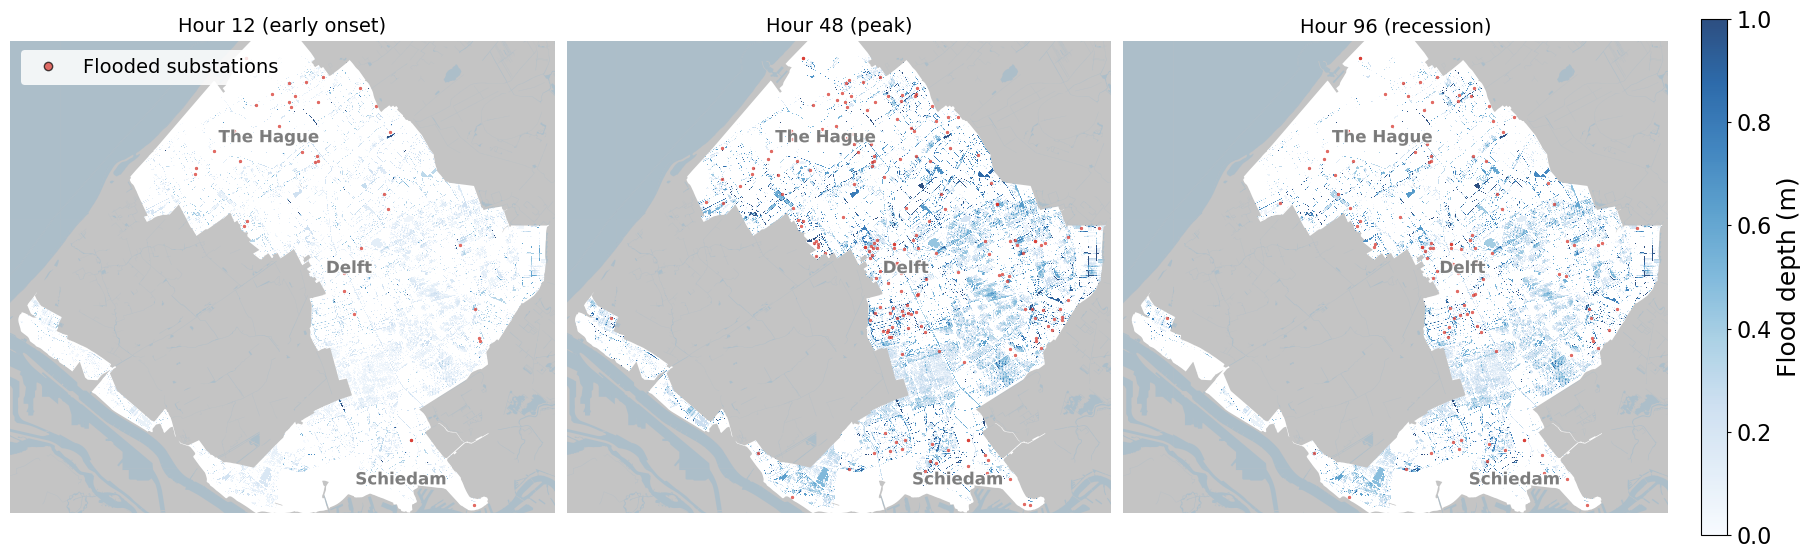

Figure 1A saved.


In [8]:
# ── Figure 1A — Hazard map snapshots ─────────────────────────────────────────
import rasterio
import matplotlib.colors as mcolors
import contextily as ctx
from matplotlib.lines import Line2D
import shapely.geometry
from pyproj import Transformer

# Path with the study area geometries, used for masking and basemap clipping
NETWORK_PATH = Path(r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\full_run\V_K_analyse\static_maxwd\network')
RD = 28992   # EPSG:28992 – Dutch RD New (metre-based, needed for area maths)

# Load the two bounding geometries in EPSG:4326, since basemap only works with that
stedin_RD      = gpd.read_file(NETWORK_PATH / 'stedin_area.geojson').to_crs(f'EPSG:{RD}')
peilgeb_RD     = gpd.read_file(Path(r'C:\repos\powerpath\powerpath\data\utilities\Peilgebieden_3857.shp')).to_crs(f'EPSG:{RD}')

stedin_union_RD  = stedin_RD.unary_union
peilgeb_union_RD = peilgeb_RD.unary_union
study_union_RD   = stedin_union_RD.intersection(peilgeb_union_RD)

HAZ_DIR = str(config['hazard_dir'])

# Sort hazard maps by timestep number extracted from filename (instead of alphabetical which puts "timestep 10" before "timestep 2")
all_tifs = sorted(
    glob.glob(HAZ_DIR + '/*.tif'),
    key=lambda x: int(os.path.basename(x).replace('timestep_', '').replace('.tif', '')))

# Hour to map indexing with major_timestep = 6h
snap_hours   = [12, 48, 96]
snap_labels  = ['Hour 12 (early onset)', 'Hour 48 (peak)', 'Hour 96 (recession)']
snap_indices = [h // MAJOR_TS for h in snap_hours]

def load_raster(fpath):
    with rasterio.open(fpath) as src:
        data   = src.read(1).astype(float)
        extent = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]
    data = np.ma.masked_where(data <= 0, data)
    # Reproject extent from EPSG:4326 to RD (EPSG:28992)
    transformer = Transformer.from_crs('EPSG:4326', f'EPSG:{RD}', always_xy=True)
    left, bottom = transformer.transform(extent[0], extent[2])
    right, top   = transformer.transform(extent[1], extent[3])
    right, top   = transformer.transform(extent[1], extent[3])
    extent = [left, right, bottom, top]

    return data, extent

# Mask out areas that are outside of study area
COLOR_OUTSIDE_STUDY     = '#c4c4c4'   # light grey — outside both (masked out completely)


def add_single_color_mask(ax, study_geom, extent, zorder=6, alpha=1.0):#0.75):
    pad = max(extent[1] - extent[0], extent[3] - extent[2]) * 0.05
    outer = shapely.geometry.box(
        extent[0] - pad, extent[2] - pad,
        extent[1] + pad, extent[3] + pad
    )

    outside = outer.difference(study_geom)
    if not outside.is_empty:
        gpd.GeoSeries([outside]).plot(
            ax=ax,
            facecolor=COLOR_OUTSIDE_STUDY,
            edgecolor='none',
            alpha=alpha,
            zorder=zorder
        )

# set up color normalization and colormap for hazard raster
all_vals = []
for idx in snap_indices:
    d, _ = load_raster(all_tifs[idx])
    all_vals.extend(d.compressed().tolist())
vmax = 1.0
norm = mcolors.Normalize(vmin=0, vmax=vmax)
cmap = plt.cm.Blues

fig, axes = plt.subplots(1, 3, figsize=(18, 10), constrained_layout=True)

context_bounds = study_union_RD.bounds
context_bounds = (context_bounds[0] - 0.1 * (context_bounds[2] - context_bounds[0]),
                context_bounds[1] - 0.1 * (context_bounds[3] - context_bounds[1]),
                context_bounds[2] + 0.1 * (context_bounds[2] - context_bounds[0]),
                context_bounds[3] + 0.1 * (context_bounds[3] - context_bounds[1]))
land_use_clipped = land_use_data.cx[context_bounds[0]:context_bounds[2], context_bounds[1]:context_bounds[3]]


# Merge all water (70s and 80s) into single "water" category
land_use_clipped['land_use'] = land_use_clipped['BG2017'].apply(lambda x: 'water' if (70 <= x < 74) | (78 <= x < 90) else f'other')

# reproject to RD for area calculations and plotting
land_use_clipped = land_use_clipped.to_crs(f'EPSG:{RD}')

water_plot = land_use_clipped[land_use_clipped['land_use'] == 'water']                              
water_plot = water_plot[~water_plot.intersects(study_union_RD)]

cities_locations = {
    'The Hague': (4.3000, 52.0700),
    'Delft': (4.3600, 52.0116),
    'Schiedam': (4.4000, 51.9167),
}

city_df = pd.DataFrame(
    [(city, lon, lat) for city, (lon, lat) in cities_locations.items()],
    columns=['city', 'lon', 'lat']
)

gdf_cities = gpd.GeoDataFrame(
    city_df,
    geometry=gpd.points_from_xy(city_df['lon'], city_df['lat']),
    crs='EPSG:4326'
).to_crs(f'EPSG:{RD}')

for ax, idx, snap_hour, label in zip(axes, snap_indices, snap_hours, snap_labels):
    data, extent = load_raster(all_tifs[idx])

    # 1 — light-grey axes background (merely visual improvement)
    ax.set_facecolor("#c4c4c4")

    # 2 — hazard raster
    im = ax.imshow(data, origin='upper', extent=extent,
                   cmap=cmap, norm=norm, interpolation='nearest',
                   alpha=0.85, zorder=2)

    # 3 — single-colour exclusion mask
    add_single_color_mask(ax, study_union_RD, extent, zorder=6)


    #outside of the study area, plot the water areas with a different color to distinguish them from the grey mask
    water_plot.plot(
        ax=ax,
        facecolor="#96b9cf",
        edgecolor='none',
        alpha=0.5,
        zorder=7
    )

    # 4 — flooded assets at this snapshot hour
    flooded_assets = timesteps_df[
        (timesteps_df['hour'] == snap_hour) & (timesteps_df['flooded'].astype(bool))
    ]['asset_id'].unique().astype(int)
    valid_ids = flooded_assets[(flooded_assets >= 0) & (flooded_assets < len(gdf_assets))]
    f_assets_gdf = gdf_assets.iloc[valid_ids].copy().to_crs(f'EPSG:{RD}')
    ax.scatter(f_assets_gdf.geometry.centroid.x, f_assets_gdf.geometry.centroid.y,
               s=3.5, c='#d73027', linewidths=0.5, alpha=0.7, zorder=4)
    
    # 6 — place-name labels only from gdf_cities
    for _, row in gdf_cities.iterrows():
        ax.text(row.geometry.x, row.geometry.y, row['city'], fontsize=12, fontweight='bold',
                ha='center', va='center', zorder=10, color="#666666", path_effects=[matplotlib.patheffects.withStroke(linewidth=2, foreground="white")], alpha=0.8)

    # Restore raster extent
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_title(label, fontsize=14)
    ax.set_axis_off()

# Getting width and height of the figure for colorbar sizing
fig_w, fig_h = fig.get_size_inches()
data_aspect = (extent[3] - extent[2]) / (extent[1] - extent[0])  # lat_range / lon_range
shrink = data_aspect * (fig_w / 3) / fig_h   # map_height_in / fig_height_in

cbar = fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02, shrink=shrink)
cbar.set_label('Flood depth (m)', fontsize=18)
cbar.ax.tick_params(labelsize=16)

red_dot_legend = Line2D(
    [0], [0],
    marker='o',
    linestyle='None',
    label='Flooded substations',
    markerfacecolor='#d73027',
    markeredgecolor='black',
    markersize=6,
    alpha=0.7
)

axes[0].legend(
    handles=[red_dot_legend],
    fontsize=14,
    loc='upper left',
    bbox_to_anchor=(0.02, 0.98),
    borderaxespad=0.0,
    frameon=True,
    framealpha=0.85,
    edgecolor='none'
)
legend = axes[0].get_legend()
legend.set_zorder(1000)

fig.savefig(FIG_DIR / 'fig1A_hazard_snapshots.png', dpi=600, bbox_inches='tight')
plt.show()
print("Figure 1A saved.")

In [9]:
# ── Figure 1B & 1C — Spatial impact by wijk (district) ───────────────────────
# 1B – cumulative VOLL-based economic disruption per wijk (full event)
# 1C – total population affected throughout the event

# ── Load boundary files ────────────────────────────────────────────────────────
wijken_raw = gpd.read_file(NETWORK_PATH / 'wijken_2022_v2.shp')
pop_raw = gpd.read_file(NETWORK_PATH / 'cbs_population_data_fixed_geometry.gpkg')
print("Boundary files loaded.")

# ── Project & clip to Figure 1A study area ────────────────────────────────────
wijken_m = wijken_raw.to_crs(RD)
wijken_m = wijken_m[wijken_m['WK_NAAM'] != 'Groot water']
wijken_m = wijken_m.clip(study_union_RD)

pop_m = pop_raw.to_crs(RD)
pop_m['cell_area_full'] = pop_m.geometry.area
pop_m = pop_m.clip(study_union_RD)
pop_m = pop_m[pop_m['aantal_inwoners'] >= 0]

# ── Build Voronoi polygons using canonical impacts.py function ────────────────
voronoi_m = create_voronoi_for_asset_type(gdf_assets, 'msls', boundary=study_union_RD)
print(f"Voronoi cells built: {len(voronoi_m)}")

# ── Load land use data and compute VOLL-weighted asset_land_use_map ───────────
# WARNING: the spatial intersection below is expensive (~several minutes)
from src.impacts import update_voll_rates, prepare_land_use_impact_data, VOLL_PER_SQM

# land_use_path = config['root_dir'] / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1.gpkg'
# land_use_data = gpd.read_file(land_use_path, driver='GPKG')
asset_land_use_map = prepare_land_use_impact_data(land_use_data, voronoi_gdf=voronoi_m)
print(f"Computed land-use intersections for {len(asset_land_use_map)} assets")

asset_to_lu = {
    aid: [
        (lu_type, area, VOLL_PER_SQM[lu_type])
        for lu_type, area in lu_dict.items()
        if lu_type in VOLL_PER_SQM
    ]
    for aid, lu_dict in asset_land_use_map.items()
}


Boundary files loaded.
Sample points: [(95150.2845220841, 433702.2131359924), (95150.2845220841, 433702.2131359924), (94384.04863411497, 433759.1802487246)]
Voronoi cells built: 3727
Consumption per square meter by land use [MWh/h/m²]:
  commercial: 0.0000046671
  industrial: 0.0000034789
  public_sector: 0.0000031629
  transport: 0.0000004713
  residential: 0.0000019616
  other: 0.0000000000

VOLL per square meter by land use [€/h/m²]:
  commercial: 0.396382
  industrial: 0.268441
  public_sector: 0.317335
  transport: 0.049920
  residential: 0.067873
  other: 0.000000
Computed land-use intersections for 3727 assets


C:\Users\peregrin\AppData\Local\Temp\ipykernel_10992\3103770857.py:56: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  affected_union = voro_nonop.geometry.unary_union


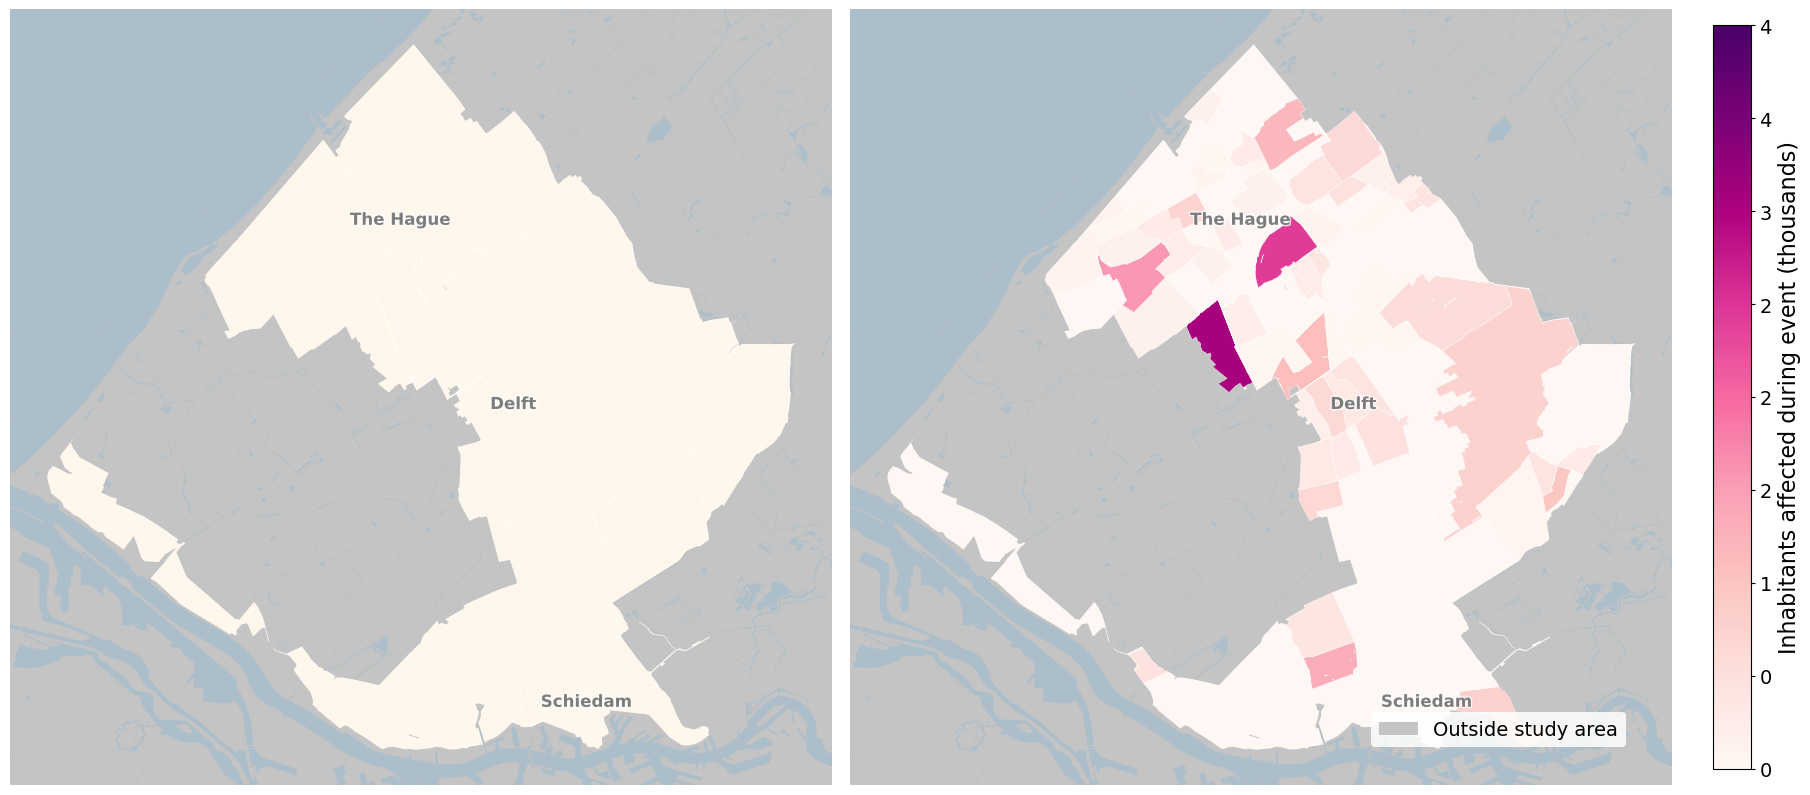

Figure 1B/C saved.
  Total disruption (full event): M€ 0
  Total disrupted Voronoi cells: 88 / 3727
  Districts with >0 pop impacted: 66 / 138
  Assumptions: Flood threshold=0.2, Fragility slope k=6.0, Repair crews=10, VOLL rates from land use, population assigned from original population-cell fragments within the event-wide affected service-area footprint.


In [79]:

# ── 1B — Economic disruption per wijk (area-weighted Voronoi allocation) ─────
asset_rate = pd.Series({
    aid: sum(area * rate for _, area, rate in lu_list)
    for aid, lu_list in asset_to_lu.items()
})  # €/h when non-operational

non_op_hours = (
    timesteps_df.loc[~timesteps_df['operational'].astype(bool)]
    .groupby('asset_id')
    .size()
)

disruption_eur = non_op_hours.mul(asset_rate).fillna(0)
disruption_eur.name = 'disruption_eur'

voronoi_m['disruption_eur'] = voronoi_m['asset_id'].map(disruption_eur).fillna(0)
voronoi_m['disruption_meur'] = voronoi_m['disruption_eur'] / 1e6

voro_for_wijk = voronoi_m[['asset_id', 'disruption_meur', 'geometry']].copy()
voro_for_wijk['voro_area'] = voro_for_wijk.geometry.area

ix_mon = gpd.overlay(
    voro_for_wijk,
    wijken_m[['WK_NAAM', 'geometry']],
    how='intersection'
)
ix_mon['ov_area'] = ix_mon.geometry.area
ix_mon['disruption_w'] = (
    ix_mon['disruption_meur']
    * ix_mon['ov_area']
    / ix_mon['voro_area'].replace(0, np.nan)
)

wijk_agg_mon = ix_mon.groupby('WK_NAAM', as_index=False)['disruption_w'].sum()
wijk_plot_mon = wijken_m.merge(wijk_agg_mon, on='WK_NAAM', how='left')
wijk_plot_mon['disruption_w'] = wijk_plot_mon['disruption_w'].fillna(0)

# ── 1C — Population affected throughout the event ─────────────────────────────
# Step 1: identify service areas whose asset is non-operational at any time
nonop_any = (
    timesteps_df.groupby('asset_id')['operational']
    .apply(lambda s: ~s.astype(bool).all())
)
nonop_any.index = nonop_any.index.astype(voronoi_m['asset_id'].dtype)

voronoi_m['non_operational_any'] = voronoi_m['asset_id'].map(nonop_any).fillna(False)
voro_nonop = voronoi_m[voronoi_m['non_operational_any']].copy()

if voro_nonop.empty:
    print("WARNING: no disrupted substations found during event")
    wijk_plot = wijken_m.copy()
    wijk_plot['pop_impacted'] = 0.0
    wijk_agg = wijk_plot[['WK_NAAM', 'pop_impacted']].copy()
else:
    # Step 2: dissolve affected service areas into one affected footprint
    affected_union = voro_nonop.geometry.unary_union

    if 'cell_area_full' not in pop_m.columns:
        raise ValueError("pop_m must contain 'cell_area_full' computed before clipping.")

    # Step 3: intersect original population cells with affected footprint
    pop_aff = gpd.overlay(
        pop_m[['geometry', 'aantal_inwoners', 'cell_area_full']],
        gpd.GeoDataFrame(geometry=[affected_union], crs=pop_m.crs),
        how='intersection'
    )
    pop_aff['aff_area'] = pop_aff.geometry.area
    pop_aff['pop_aff'] = (
        pop_aff['aantal_inwoners']
        * pop_aff['aff_area']
        / pop_aff['cell_area_full'].replace(0, np.nan)
    )

    # Assign a stable source id before splitting by wijk
    pop_aff = pop_aff.reset_index(drop=True)
    pop_aff['pop_aff_id'] = np.arange(len(pop_aff))

    # Step 4: allocate affected population fragments to wijken
    ix_w = gpd.overlay(
        pop_aff[['pop_aff_id', 'pop_aff', 'geometry']],
        wijken_m[['geometry', 'WK_NAAM']],
        how='intersection'
    )
    ix_w['ix_area'] = ix_w.geometry.area

    # Redistribute each affected population fragment only across its own wijk splits
    area_per_fragment = ix_w.groupby('pop_aff_id')['ix_area'].transform('sum')
    ix_w['pop_impacted'] = (
        ix_w['pop_aff']
        * ix_w['ix_area']
        / area_per_fragment.replace(0, np.nan)
    )

    wijk_agg = ix_w.groupby('WK_NAAM', as_index=False)['pop_impacted'].sum()
    wijk_plot = wijken_m.merge(wijk_agg, on='WK_NAAM', how='left')
    wijk_plot['pop_impacted'] = wijk_plot['pop_impacted'].fillna(0.0)
    wijk_plot['pop_impacted_thousands'] = wijk_plot['pop_impacted'] / 1000.0

# ── Plot ───────────────────────────────────────────────────────────────────────
fig_1bc, (ax1B, ax1C) = plt.subplots(1, 2, figsize=(18, 10), constrained_layout=True)
int_fmt = FuncFormatter(lambda x, p: f"{x:,.0f}")

for ax, gdf_plot, col, cmap, legend_label, title in [
    (ax1B, wijk_plot_mon, "disruption_w", "OrRd",
     "Cumulative monetary impact (M€)",
     "B  Monetary impact by district\n(cumulative, full event)"),
    (ax1C, wijk_plot, "pop_impacted_thousands", "RdPu",
     "Inhabitants affected during event (thousands)",
     "C  Population impact by district\n(affected at any time during the event)"),
]:
    vals = gdf_plot[col].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]

    vmin = 0.0  # always start colorbar at zero

    if vals.size == 0:
        vmax = 1.0
        show_legend = False
    else:
        raw_max = float(vals.max())

        if raw_max <= 0:
            vmax = 1.0
            show_legend = False
        else:
            # round up to 1 significant digit: 6785 -> 7000, 83 -> 90, 0.83 -> 0.9
            scale = 10 ** np.floor(np.log10(raw_max))
            vmax = np.ceil(raw_max / scale) * scale
            show_legend = True

    if show_legend:
        gdf_plot.plot(
            column=col, ax=ax, cmap=cmap,
            edgecolor="white", linewidth=0.3,
            vmin=vmin, vmax=vmax,
            legend=True,
            legend_kwds={"shrink": 0.75, "label": legend_label, "format": int_fmt},
        )
        # style colorbar created by this plot call
        cax = fig_1bc.axes[-1]
        if cax is not ax:
            cax.set_ylabel(legend_label, fontsize=16)
            cax.tick_params(labelsize=14)
    else:
        gdf_plot.plot(
            column=col, ax=ax, cmap=cmap,
            edgecolor="white", linewidth=0.3,
            vmin=vmin, vmax=vmax,
            legend=False,
        )

    extent = [ax.get_xlim()[0], ax.get_xlim()[1], ax.get_ylim()[0], ax.get_ylim()[1]]
    add_single_color_mask(ax, study_union_RD, extent, zorder=7)
    #outside of the study area, plot the water areas with a different color to distinguish them from the grey mask
    water_plot.plot(
        ax=ax,
        facecolor="#96b9cf",
        edgecolor='none',
        alpha=0.5,
        zorder=8
    )

    for _, row in gdf_cities.iterrows():
        ax.text(
            row.geometry.x, row.geometry.y, row["city"],
            fontsize=12, fontweight="bold", ha="center", va="center",
            zorder=10, color="#666666",
            path_effects=[matplotlib.patheffects.withStroke(linewidth=2, foreground="white")],
            alpha=0.8
        )

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    # ax.set_title(title, fontsize=8, fontweight="bold", loc="left")
    ax.set_axis_off()

# Legend explaining the exclusion zone
outside_legend = mpatches.Patch(
    facecolor=COLOR_OUTSIDE_STUDY,
    label='Outside study area'
)

fig_1bc.legend(
    handles=[outside_legend],
    fontsize=14,
    loc='lower right',
    bbox_to_anchor=(0.9, 0.15),
    borderaxespad=0.0,
    frameon=True,
    framealpha=0.85,
    edgecolor='none'
)

fig_1bc.savefig(FIG_DIR / 'fig1B_C_spatial_impacts.png', dpi=600, bbox_inches='tight')
plt.show()

print("Figure 1B/C saved.")
print(f"  Total disruption (full event): M€ {voronoi_m['disruption_meur'].sum():,.0f}")
print(f"  Total disrupted Voronoi cells: {int(voronoi_m['non_operational_any'].sum())} / {len(voronoi_m)}")
print(f"  Districts with >0 pop impacted: {(wijk_plot['pop_impacted'] > 0).sum()} / {len(wijk_plot)}")
print("  Assumptions: Flood threshold=0.2, Fragility slope k=6.0, Repair crews=10, VOLL rates from land use, population assigned from original population-cell fragments within the event-wide affected service-area footprint.")

In [11]:
# Total people affected throughout the event (for reporting in text)
total_pop_impacted = wijk_plot['pop_impacted'].sum()
print(f"\nTotal population impacted at any time during the event: {int(total_pop_impacted)} inhabitants")


Total population impacted at any time during the event: 24960 inhabitants


Wijken loaded and clipped: 138
Sample points: [(95150.2845220841, 433702.2131359924), (95150.2845220841, 433702.2131359924), (94384.04863411497, 433759.1802487246)]


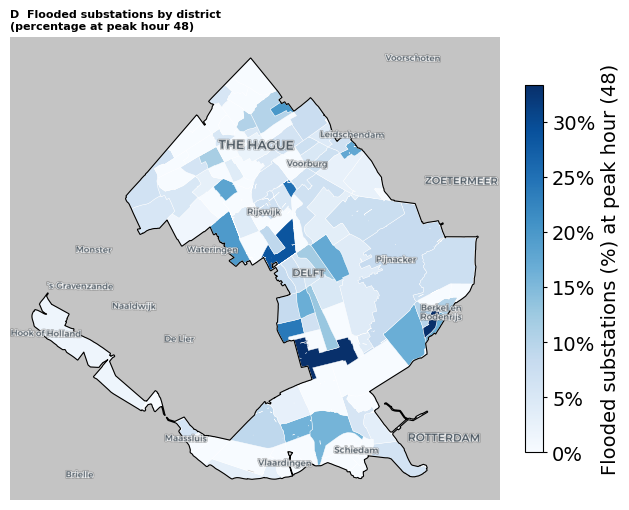

Figure 1D saved: fig1D_pct_flooded_by_wijk.png
  Peak hour: 48
  Total substations in study area: 3727
  Flooded substations at peak: 198
  Wijken with ≥1 substation: 124


In [12]:
# ── Figure 1D — % flooded substations by wijk (peak hour) ─────────────────────
from matplotlib.ticker import FuncFormatter
import pandas as pd
import geopandas as gpd
import numpy as np
import contextily as ctx

PEAK_HOUR = snap_hours[1]  # 48

# ── Load wijk boundaries ─────────────────────────────────────────────────────
wijken_raw = gpd.read_file(NETWORK_PATH / 'wijken_2022_v2.shp')
wijken_m = wijken_raw.to_crs(RD)
wijken_m = wijken_m[wijken_m['WK_NAAM'] != 'Groot water']
wijken_m = wijken_m.clip(study_union_RD)

print(f"Wijken loaded and clipped: {len(wijken_m)}")

# ── Voronoi cells (one per substation) ───────────────────────────────────────
voronoi_m = create_voronoi_for_asset_type(gdf_assets, 'msls', boundary=study_union_RD)
voronoi_m = voronoi_m.to_crs(RD)

# Use centroids for assignment (same as Fig 1B)
voro_pts = voronoi_m[['asset_id', 'geometry']].copy()
voro_pts['geometry'] = voro_pts.geometry.centroid

# ── Flooded flag at peak hour ────────────────────────────────────────────────
flooded_at_peak = (
    timesteps_df[timesteps_df['hour'] == PEAK_HOUR]
    [['asset_id', 'flooded']]
    .assign(flooded=lambda df: df['flooded'].astype(bool))
)

voro_pts = voro_pts.merge(flooded_at_peak, on='asset_id', how='left')
voro_pts['flooded'] = voro_pts['flooded'].fillna(False)

# ── Assign substations to wijk and aggregate ─────────────────────────────────
voro_join = gpd.sjoin(
    voro_pts[['asset_id', 'flooded', 'geometry']],
    wijken_m[['WK_NAAM', 'geometry']],
    how='left',
    predicate='within'
)

wijk_agg = (
    voro_join.groupby('WK_NAAM')
    .agg(
        n_total=('asset_id', 'count'),
        n_flooded=('flooded', 'sum')
    )
    .reset_index()
)

wijk_agg['pct_flooded'] = np.where(
    wijk_agg['n_total'] > 0,
    100.0 * wijk_agg['n_flooded'] / wijk_agg['n_total'],
    0.0
)

wijk_plot = wijken_m.merge(wijk_agg, on='WK_NAAM', how='left')
wijk_plot['pct_flooded'] = wijk_plot['pct_flooded'].fillna(0.0)

# ── Plot ────────────────────────────────────────────
fig_1d, ax1D = plt.subplots(1, 1, figsize=(6.2, 5.2), constrained_layout=True)

pct_fmt = FuncFormatter(lambda x, p: f'{x:.0f}%')

wijk_plot.plot(
    column='pct_flooded',
    ax=ax1D,
    cmap='Blues',
    edgecolor='white',
    linewidth=0.3,
    legend=True,
    legend_kwds={
        'shrink': 0.75,
        'label': 'Flooded substations (%) at peak hour (48)',
        'format': pct_fmt
    }
)

extent = [
    ax1D.get_xlim()[0], ax1D.get_xlim()[1],
    ax1D.get_ylim()[0], ax1D.get_ylim()[1]
]

# Outside-study-area mask
add_single_color_mask(ax1D, study_union_RD, extent, zorder=7)

# Study area outline
gpd.GeoSeries([study_union_RD]).buffer(20).plot(
    ax=ax1D,
    facecolor='none',
    edgecolor='black',
    linewidth=0.8,
    zorder=8
)

# Place-name labels only
ctx.add_basemap(
    ax1D,
    crs=f'EPSG:{RD}',
    source='https://a.basemaps.cartocdn.com/light_only_labels/{z}/{x}/{y}@3x.png',
    attribution=False,
    zoom=11,
    zorder=9
)

ax1D.set_xlim(extent[0], extent[1])
ax1D.set_ylim(extent[2], extent[3])

ax1D.set_title(
    'D  Flooded substations by district\n(percentage at peak hour 48)',
    fontsize=8,
    fontweight='bold',
    loc='left'
)

ax1D.set_axis_off()

fig_1d.savefig(FIG_DIR / 'fig1D_pct_flooded_by_wijk.png', dpi=600, bbox_inches='tight')
plt.show()

print("Figure 1D saved: fig1D_pct_flooded_by_wijk.png")
print(f"  Peak hour: {PEAK_HOUR}")
print(f"  Total substations in study area: {len(voro_pts)}")
print(f"  Flooded substations at peak: {voro_pts['flooded'].sum()}")
print(f"  Wijken with ≥1 substation: {(wijk_agg['n_total'] > 0).sum()}")

Buurten boundary file loaded.
Buurten after clip: 494
Sample points: [(95150.2845220841, 433702.2131359924), (95150.2845220841, 433702.2131359924), (94384.04863411497, 433759.1802487246)]
Voronoi cells built: 3727


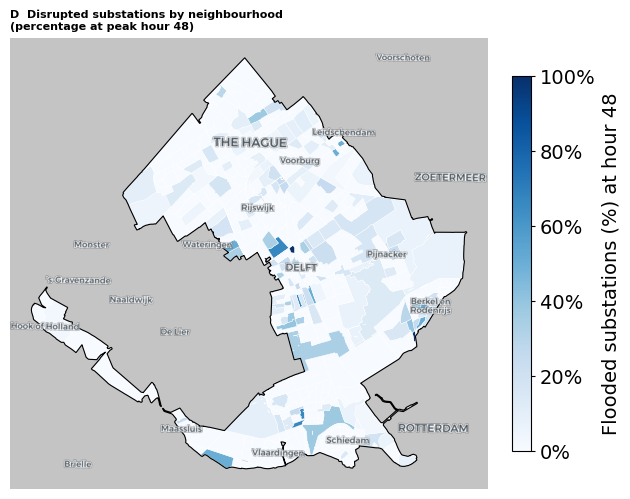

Figure 1D saved: fig1D_pct_flooded_by_buurt.png
  Peak hour: 48
  Total substations assigned to buurten: 3,718
  Total flooded substations at peak: 198
  Buurten with >=1 substation: 428


In [13]:
# ── Figure 1D — % substations disrupted by buurt (neighbourhood) ──────────────
# Uses same visual style as Fig 1B/C and the same study area mask as Fig 1A.
# Metric: percentage of substations disrupted at peak hour (hour 48):
#         100 * (# substations with operational==False in buurt) / (total substations in buurt)

# --- Input boundary file (buurten) ---
buurten_path = NETWORK_PATH / 'buurten_2022_v2.shp'
buurten_raw = gpd.read_file(buurten_path)
print("Buurten boundary file loaded.")

# --- Project & clip to study area (same as Fig 1A / 1B-C) ---
buurten_m = buurten_raw.to_crs(RD).clip(study_union_RD)

# Optional: remove water-only polygons if the attribute exists
for col in ['BU_NAAM', 'BU_NAAM_2022', 'BUURTNAAM']:
    if col in buurten_m.columns:
        buurten_name_col = col
        break
else:
    buurten_name_col = None  # fall back to index if no name column found

# Some CBS layers include "Groot water" or similar; drop if present
if buurten_name_col is not None:
    buurten_m = buurten_m[buurten_m[buurten_name_col] != 'Groot water']

print(f"Buurten after clip: {len(buurten_m)}")

# --- Voronoi cells (one per substation) ---
# If voronoi_m already exists from Fig 1B/C, you can skip rebuilding and just ensure CRS matches.
# voronoi_m = voronoi_m.to_crs(RD)

voronoi_m = create_voronoi_for_asset_type(gdf_assets, 'msls', boundary=study_union_RD)
voronoi_m = voronoi_m.to_crs(RD)
print(f"Voronoi cells built: {len(voronoi_m)}")

# Use centroids for spatial join (same as Fig 1B)
voro_pts = voronoi_m[['asset_id', 'geometry']].copy()
voro_pts['geometry'] = voro_pts.geometry.centroid

# --- Peak hour flooded flag (use flooded==True) ---
PEAK_HOUR = 48

flooded_at_peak = (
    timesteps_df[timesteps_df['hour'] == PEAK_HOUR][['asset_id', 'flooded']]
    .assign(flooded=lambda df: df['flooded'].astype(bool))
    [['asset_id', 'flooded']]
)

# Merge flooded flag onto points
voro_pts = voro_pts.merge(flooded_at_peak, on='asset_id', how='left')
voro_pts['flooded'] = voro_pts['flooded'].fillna(False)

# --- Assign each substation to a buurt, then compute % flooded ---
# Use buurt name if available; else use index
join_cols = ['geometry']
if buurten_name_col is not None:
    join_cols.append(buurten_name_col)

voro_join = gpd.sjoin(
    voro_pts[['asset_id', 'flooded', 'geometry']],
    buurten_m[join_cols],
    how='left',
    predicate='within'
)

group_key = buurten_name_col if buurten_name_col is not None else 'index_right'

agg = (
    voro_join.groupby(group_key)
    .agg(
        n_total=('asset_id', 'count'),
        n_flooded=('flooded', 'sum')
    )
    .reset_index()
)

agg['pct_flooded'] = np.where(
    agg['n_total'] > 0,
    100.0 * agg['n_flooded'] / agg['n_total'],
    0.0
)

# Merge back to buurten polygons for plotting
if buurten_name_col is not None:
    buurten_plot = buurten_m.merge(agg, on=buurten_name_col, how='left')
else:
    buurten_plot = buurten_m.merge(agg, left_index=True, right_on='index_right', how='left')

buurten_plot['pct_flooded'] = buurten_plot['pct_flooded'].fillna(0.0)

# --- Plot ---
fig_1d, ax1D = plt.subplots(1, 1, figsize=(6.2, 5.2), constrained_layout=True)

pct_fmt = FuncFormatter(lambda x, p: f'{x:.0f}%')

plot_kwargs = dict(
    column='pct_flooded',
    ax=ax1D,
    cmap='Blues',
    edgecolor='white',
    linewidth=0.3,
    legend=True,
    legend_kwds={'shrink': 0.75, 'label': 'Flooded substations (%) at hour 48', 'format': pct_fmt}
)

buurten_plot.plot(**plot_kwargs)

extent = [ax1D.get_xlim()[0], ax1D.get_xlim()[1], ax1D.get_ylim()[0], ax1D.get_ylim()[1]]
add_single_color_mask(ax1D, study_union_RD, extent, zorder=7)

gpd.GeoSeries([study_union_RD]).buffer(20).plot(
    ax=ax1D,
    facecolor='none',
    edgecolor='black',
    linewidth=0.8,
    zorder=8
)

ctx.add_basemap(
    ax1D,
    crs=f'EPSG:{RD}',
    source='https://a.basemaps.cartocdn.com/light_only_labels/{z}/{x}/{y}@3x.png',
    attribution=False,
    zoom=11,
    zorder=9
)

ax1D.set_xlim(extent[0], extent[1])
ax1D.set_ylim(extent[2], extent[3])

ax1D.set_title('D  Disrupted substations by neighbourhood\n(percentage at peak hour 48)', fontsize=8, fontweight='bold', loc='left')
ax1D.set_axis_off()

fig_1d.savefig(FIG_DIR / 'fig1D_pct_flooded_by_buurt.png', dpi=600, bbox_inches='tight')
plt.show()

print("Figure 1D saved: fig1D_pct_flooded_by_buurt.png")
print(f"  Peak hour: {PEAK_HOUR}")
print(f"  Total substations assigned to buurten: {agg['n_total'].sum():,.0f}")
print(f"  Total flooded substations at peak: {agg['n_flooded'].sum():,.0f}")
print(f"  Buurten with >=1 substation: {(agg['n_total'] > 0).sum():,d}")

Loaded 3000 experiments
  Crews range : 1–50
  Policies    : ['baseline_road', 'population_impacts_road', 'monetary_impacts_road']
  Using 'baseline_road': 1000 experiments
Total substations in study area: 3727


C:\Users\peregrin\AppData\Local\Temp\ipykernel_10992\366832462.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


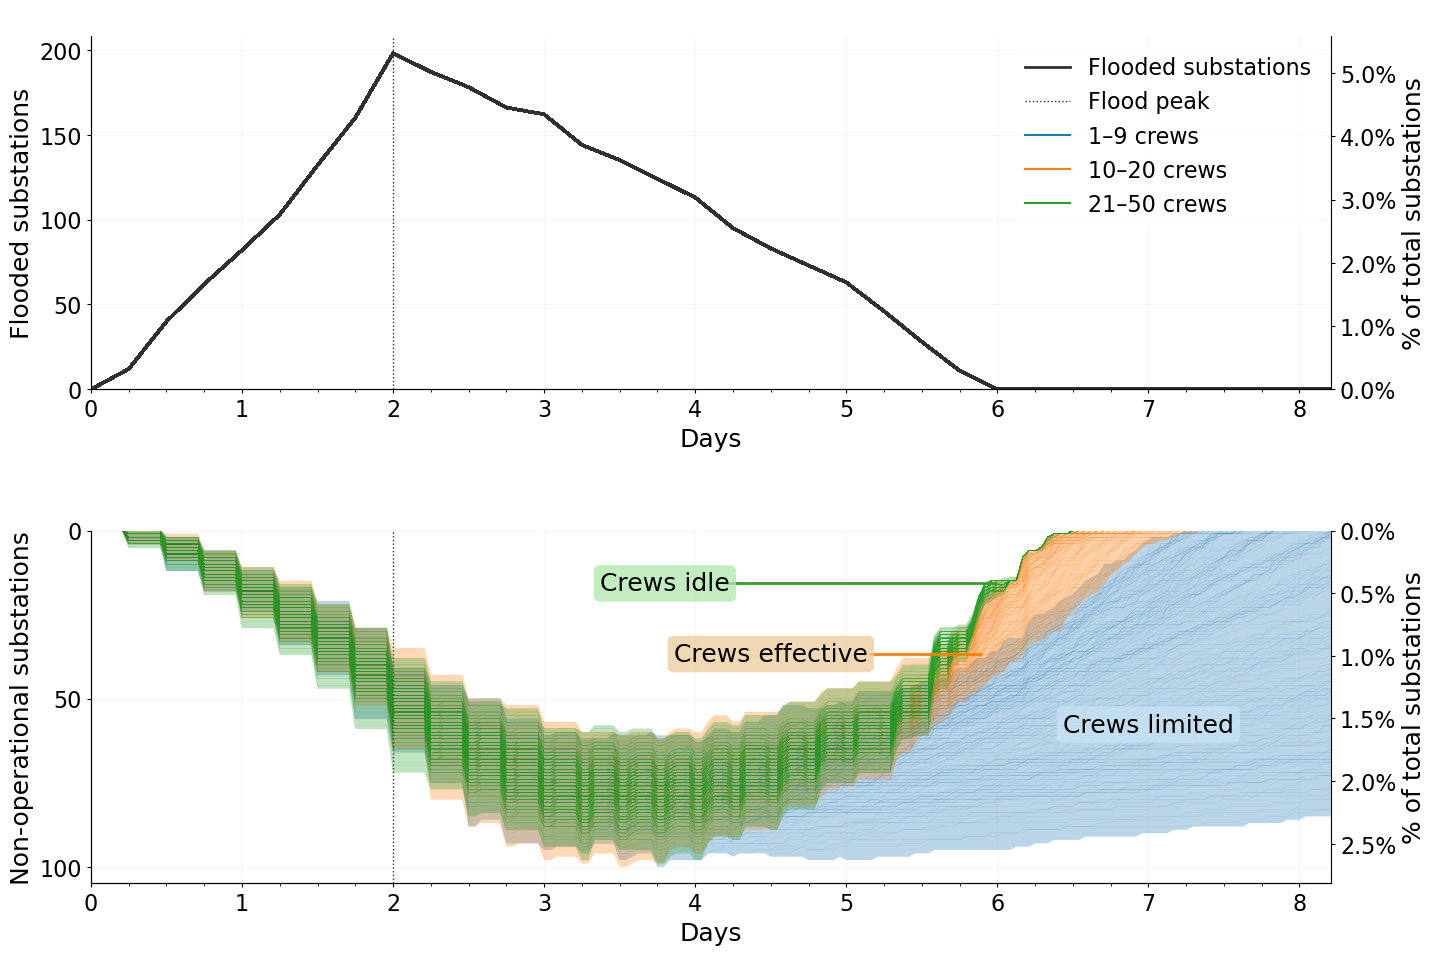

Figure 2 saved.
  Regime counts: {'21–50 crews': 600, '10–20 crews': 220, '1–9 crews': 180}


In [14]:
# ── Figure 2 — Repair capacity and recovery regimes ───────────────────────────
from ema_workbench.analysis.plotting import lines
from scipy.interpolate import interp1d

# Load the all-crews dataset (1–50 repair crews, spans all three regimes)
(exp2_raw, out2_raw) = load_results(out_dir / results_dict['all_crews'])
exp2 = pd.DataFrame(exp2_raw)
print(f"Loaded {len(exp2)} experiments")
print(f"  Crews range : {exp2['number_repair_crews'].min()}–{exp2['number_repair_crews'].max()}")
print(f"  Policies    : {list(exp2['policy'].unique())}")

# Filter to baseline policy to isolate the repair-capacity effect
baseline_pol = next(p for p in exp2['policy'].unique() if 'baseline' in p.lower())
mask_base    = exp2['policy'] == baseline_pol
exp2_b = exp2[mask_base].copy()
out2_b = {k: np.array(v)[mask_base.values] for k, v in out2_raw.items()}
print(f"  Using '{baseline_pol}': {len(exp2_b)} experiments")

n_steps = list(out2_b.values())[0].shape[1]
n_exp   = out2_b[next(iter(out2_b))].shape[0]

# Find the total number of substations in study area by intersecting the gdf_assets with the study area geometry
n_total = len(voronoi_m)  # Each Voronoi cell corresponds to one substation
print(f"Total substations in study area: {n_total}")

# Derive non-operational count
if 'operational' in out2_b:
    out2_b['non_operational'] = out2_b['operational'][0][0] - out2_b['operational']

# Flooded substations — deterministic: all experiments share the same signal.
# The value only changes every MAJOR_TS steps, so spline through the 6-hour samples.
if 'flooded' in out2_b:
    flooded_det = out2_b['flooded'][0].astype(float)   # one representative row
    sample_idx  = np.arange(0, n_steps, MAJOR_TS)
    full_idx    = np.arange(n_steps)
    spl = interp1d(sample_idx, flooded_det[sample_idx],
                   kind='slinear', fill_value='extrapolate')
    flooded_smooth = np.clip(spl(full_idx), 0, None)
    # Broadcast identical rows so lines() treats it as a shared deterministic curve
    out2_b['flooded_smooth'] = np.tile(flooded_smooth, (n_exp, 1))

# Assign regime category from crew count
REGIME_LABELS = [
    '1–9 crews',
    '10–20 crews',
    '21–50 crews',
]

REGIME_COLORS = {
    'backlog': '#1f78b4',        # blue (1–9 crews)
    'intermediate': '#ff7f00',   # orange (10–20 crews)
    'diminishing': '#33a02c',    # green (>20 crews)
}

exp2_b['regime'] = pd.cut(
    exp2_b['number_repair_crews'],
    bins=[0, 9, 20, int(exp2_b['number_repair_crews'].max())],
    labels=REGIME_LABELS,
).astype(str)

OUTCOMES_TO_SHOW = [
    'flooded_smooth',           # deterministic — added first
    'non_operational',
    # 'monetary_impact_total',    
    # 'affected_population',
]

fig, axes = lines(
    exp2_b,
    out2_b,
    outcomes_to_show=OUTCOMES_TO_SHOW,
    group_by='regime',
    grouping_specifiers=REGIME_LABELS,
    legend=True,
    show_envelope=True,
)

# Style the axes
# Relabel x-axis ticks to days
tick_pos = np.linspace(0, n_steps - 6, 9, dtype=int)
tick_pos_minor = np.arange(0, n_steps, 6)  # every 6 hours

max_flooded = out2_b['flooded_smooth'].max()
y_tick_pos_ax1 = np.linspace(0, np.ceil(max_flooded/100)*100, 5)
axes['flooded_smooth'].set_yticks(y_tick_pos_ax1)

# For all axes
for ax in axes.values():
    ax.set_xticks(tick_pos_minor, minor=True)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f'{t / 24:.0f}' for t in tick_pos], fontsize=16)
    ax.set_xlabel('Days', fontsize=18)
    ax.set_title(" ", fontsize=18, fontweight='bold')
    ax.grid(True, alpha=0.1)
    ax.set_ylim(bottom=0)
    yticks = ax.get_yticks()
    ax.yaxis.set_major_locator(plt.FixedLocator(yticks))
    ax.set_yticklabels([f'{int(t)}' for t in yticks], fontsize=16)

# Friendly y-axis labels for the two derived outcomes
axes['flooded_smooth'].set_ylabel('Flooded substations', fontsize=18)
axes['non_operational'].set_ylabel('Non-operational substations', fontsize=18)

# Style individual lines
for i, ax in enumerate(axes.values()):
    if i == 0:
        for ln in ax.get_lines():
            ln.set_linewidth(2.0)
            ln.set_alpha(1.0)
            ln.set_color("#303030")  # dark gray for the deterministic flooded curve
        continue
    for ln in ax.get_lines():
        ln.set_linewidth(0.1)
        ln.set_alpha(0.5)

# ── Invert non_operational y-axis: 0 (all working) at top, max outage at bottom
axes['non_operational'].invert_yaxis()


ax = axes['non_operational']

# Get y-limits after inversion (important)
ymin, ymax = ax.get_ylim()

# --- BACKLOG: dominant late-stage non-operational backlog (blue area) ---
# Annotate with text box
val_dist=[3.8, 6.5]

ax.text(
    7*24, ymin + (ymax - ymin) * 0.45,             # inside blue envelope
    'Crews limited',
    fontsize=18,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.25',
              fc="#c8e3f5", ec='none', alpha=0.75),
    zorder=10
)

# --- INTERMEDIATE: bottom of the U-shaped recovery ---
ax.text(
     4.5*24, ymin + (ymax - ymin) * 0.65,
    'Crews effective',
    fontsize=18,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.25',
              fc="#ebcb9a", ec='none', alpha=0.75),
    zorder=10
)

# Horizontal leader — Intermediate
y_inter = ymin + (ymax - ymin) * 0.65
ax.hlines(
    y=y_inter,
    xmin=5.15 * 24,
    xmax=5.9 * 24,   # bottom of the U
    colors=REGIME_COLORS['intermediate'],
    linewidth=2.0,
    zorder=9
)


# --- DIMINISHING RETURNS: left arm of the U ---
ax.text(
    3.8*24, ymin + (ymax - ymin) * 0.85,
    'Crews idle',
    fontsize=18,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.25',
              fc="#aee7aa", ec='none', alpha=0.75),
    zorder=10
)

# Horizontal leader — Diminishing returns
y_dim = ymin + (ymax - ymin) * 0.85
ax.hlines(
    y=y_dim,
    xmin=4.2 * 24,
    xmax=6.0 * 24,   # left arm of the U
    colors=REGIME_COLORS['diminishing'],
    linewidth=2.0,
    zorder=9
)

# Vertical dotted line at flood peak 
for ax in axes.values():
    ax.vlines(
        x=2*24,  # 48 hours
        ymin=ax.get_ylim()[0],
        ymax=ax.get_ylim()[1],
        colors='#303030',
        linewidth=1.0,
        linestyles='dotted',
        zorder=8
    )

# ── Secondary y-axes: percentage of total substations ────────────────────────
for outcome_name, ax in axes.items():
    ax2 = ax.twinx()
    ylo, yhi = ax.get_ylim()
    ax2.set_ylim(ylo / n_total * 100, yhi / n_total * 100)
    ax2.set_ylabel('% of total substations', fontsize=18)
    ax2.tick_params(axis='y', labelsize=16)
    ax2.spines['right'].set_visible(True)   # rcParams hides right spine by default
    ax2.spines['top'].set_visible(False)
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))


# ── Legend: deterministic flooding handle + three regime handles ──────────────
# Collect regime handles/labels from whichever axes owns them, then remove all legends
regime_handles, regime_labels = [], []
for ax in axes.values():
    leg = ax.get_legend()
    if leg is not None:
        regime_handles = leg.legend_handles
        regime_labels  = [t.get_text() for t in leg.get_texts()]
        leg.remove()

# Deduplicate (lines() may add identical entries on each sub-axes)
seen = {}
for h, l in zip(regime_handles, regime_labels):
    if l not in seen:
        seen[l] = h
regime_handles = list(seen.values())
regime_labels  = list(seen.keys())

# Manual handle for the deterministic grey flooding line
from matplotlib.lines import Line2D as _Line2D
flood_handle = _Line2D([0], [0], color='#303030', lw=2.0, label='Flooded substations')
peak_flood_handle = _Line2D([0], [0], color='#303030', lw=1.0, linestyle='dotted', label='Flood peak')

# Place single legend on the first (flooded_smooth) axes
axes['flooded_smooth'].legend(
    [flood_handle, peak_flood_handle] + regime_handles,
    [flood_handle.get_label(), peak_flood_handle.get_label()] + regime_labels,
    ncol=1, fontsize=16,
    loc='upper right', frameon=True, framealpha=0.85, edgecolor='none',
)


fig.set_size_inches(16, len(axes) * 5.5)  # adjust height based on number of subplots
plt.tight_layout()

fig.savefig(FIG_DIR / 'fig2_recovery_regimes.png', dpi=600, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")
print(f"  Regime counts: {exp2_b['regime'].value_counts().to_dict()}")

In [15]:
# Find the mean, min, and max maximum non-operational substations accross all runs
max_non_op = out2_b['non_operational'].max(axis=1)
mean_max_non_op = max_non_op.mean()
min_max_non_op = max_non_op.min()
max_max_non_op = max_non_op.max()

print(f"Max non-operational substations (mean ± std): {mean_max_non_op:.1f} ± {max_non_op.std():.1f}")
print(f"Max non-operational substations (min–max): {min_max_non_op:.0f}–{max_max_non_op:.0f}")


Max non-operational substations (mean ± std): 79.7 ± 6.9
Max non-operational substations (min–max): 63–100


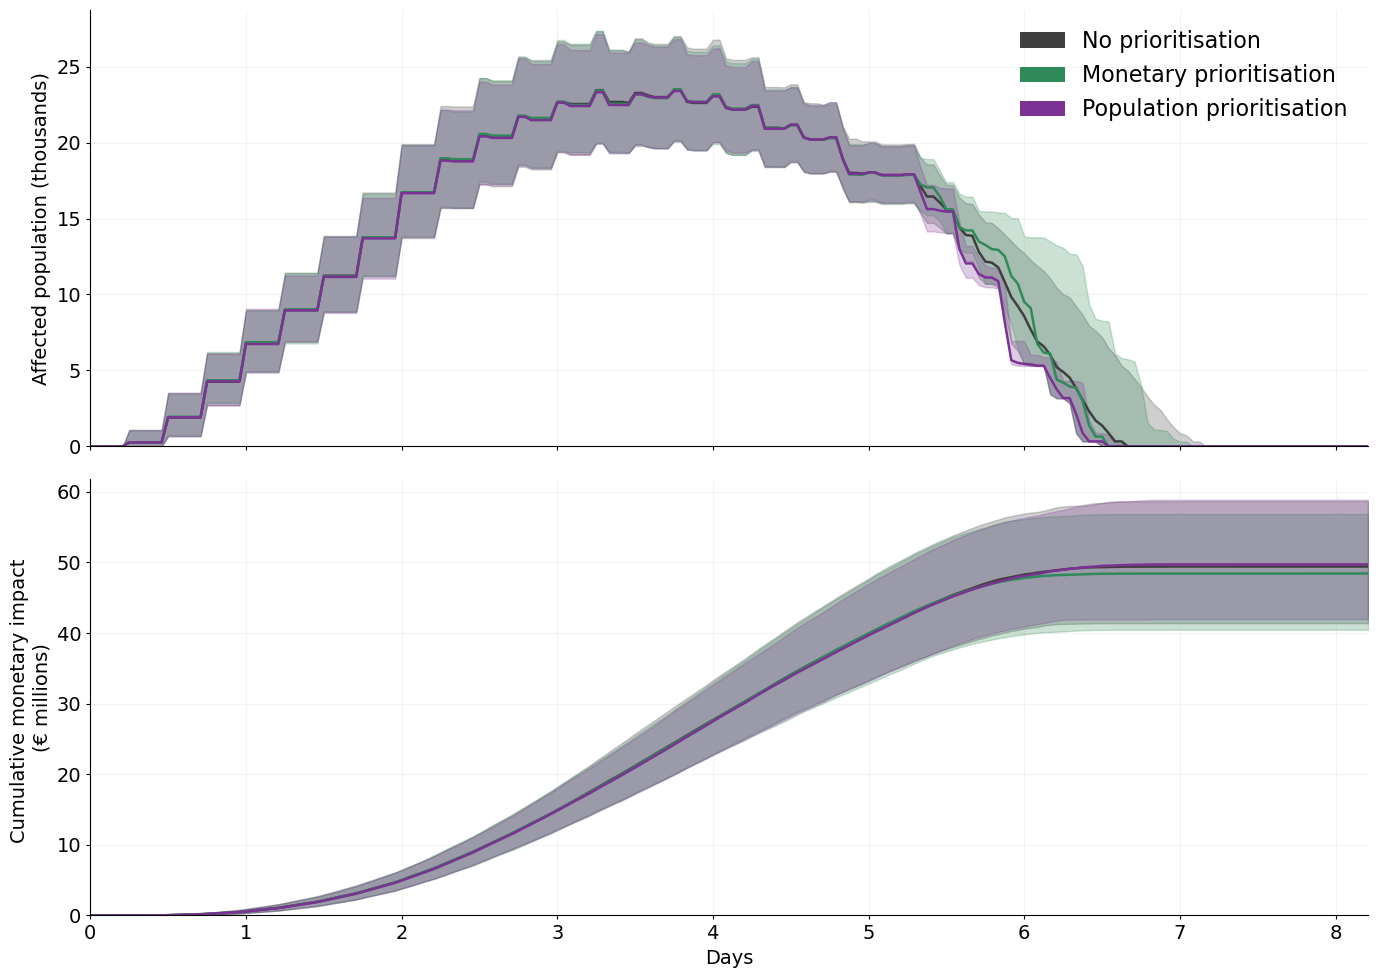

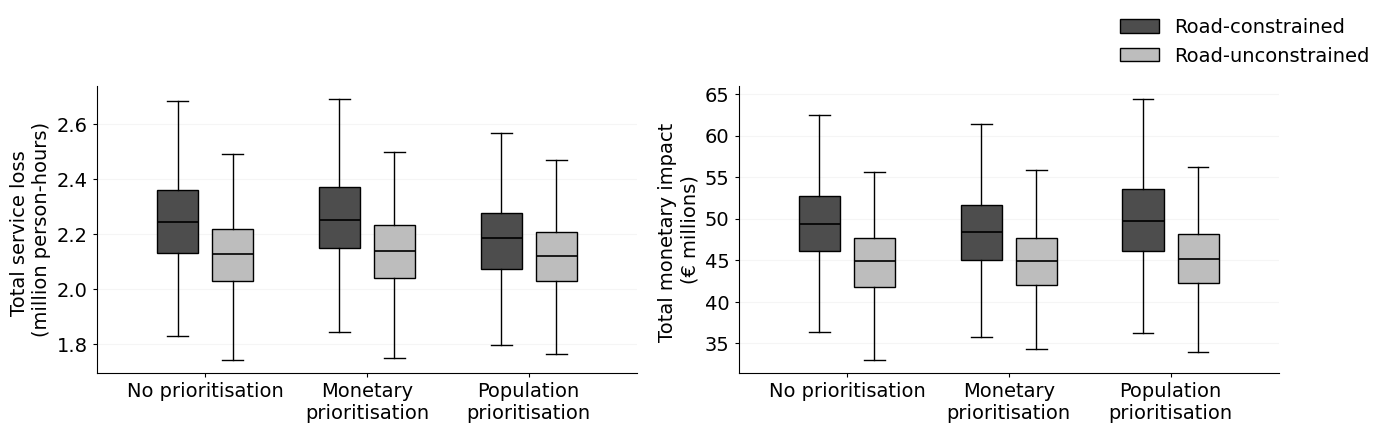

Saved: fig3_soft_measures_temporal.png
Saved: fig3_soft_measures_bars.png


In [16]:
import numpy as np
import pandas as pd

# ── Figure 3 — Soft measures: prioritisation + road accessibility ────────────
# Clean version: no additional scaling logic, raw outcome units.
# Split Figure 3 into two outputs (temporal + bars), then stop the rest of this cell.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

(exp_raw, out_raw) = load_results(out_dir / results_dict['no_adaptations'])
exp = pd.DataFrame(exp_raw)
out = {k: np.array(v) for k, v in out_raw.items()}

CREW_MIN_F3, CREW_MAX_F3 = 10, 20
crew_mask = (exp["number_repair_crews"] >= CREW_MIN_F3) & (exp["number_repair_crews"] <= CREW_MAX_F3)

STRATEGIES = ["No prioritisation", "Monetary-based", "Population-based"]
POLICY_MAP = {
    "No prioritisation": {"road": "baseline_road", "unconstrained": "baseline_unconstrained"},
    "Monetary-based": {"road": "monetary_impacts_road", "unconstrained": "monetary_impacts_unconstrained"},
    "Population-based": {"road": "population_impacts_road", "unconstrained": "population_impacts_unconstrained"},
}

required_outcomes = ["affected_population", "monetary_impact_total"]
missing = [f"Missing outcome: {k}" for k in required_outcomes if k not in out]

available_policies = set(exp["policy"].unique())
for s in STRATEGIES:
    for mode in ["road", "unconstrained"]:
        pol = POLICY_MAP[s][mode]
        if pol not in available_policies:
            missing.append(f"Missing policy: {pol}")
        elif not ((crew_mask) & (exp["policy"] == pol)).any():
            missing.append(f"No runs for {pol} in crew range {CREW_MIN_F3}-{CREW_MAX_F3}")

if missing:
    raise ValueError("Figure 3 cannot be generated:\n - " + "\n - ".join(missing))

def _series_stats(outcome, policy):
    m = crew_mask & (exp["policy"] == policy)
    d = out[outcome][m.values]
    return {
        "median": np.median(d, axis=0),
        "p05": np.percentile(d, 5, axis=0),
        "p95": np.percentile(d, 95, axis=0),
    }

def _sum_over_time(outcome, policy):
    m = crew_mask & (exp["policy"] == policy)
    return out[outcome][m.values].sum(axis=1)

def _final_value(outcome, policy):
    m = crew_mask & (exp["policy"] == policy)
    return out[outcome][m.values][:, -1]

def _dist_stats(x):
    p05, med, p95 = np.percentile(x, [5, 50, 95])
    return med, med - p05, p95 - med

days = np.arange(out["affected_population"].shape[1]) / 24.0

ts_pop = {
    s: {k: v / 1e3 for k, v in _series_stats("affected_population", POLICY_MAP[s]["road"]).items()}
    for s in STRATEGIES
}
ts_mon = {
    s: {k: v / 1e6 for k, v in _series_stats("monetary_impact_total", POLICY_MAP[s]["road"]).items()}
    for s in STRATEGIES
}

tot_pop_road = {s: _sum_over_time("affected_population", POLICY_MAP[s]["road"]) / 1e6 for s in STRATEGIES}
tot_pop_uncon = {s: _sum_over_time("affected_population", POLICY_MAP[s]["unconstrained"]) / 1e6 for s in STRATEGIES}
tot_mon_road = {s: _final_value("monetary_impact_total", POLICY_MAP[s]["road"]) / 1e6 for s in STRATEGIES}
tot_mon_uncon = {s: _final_value("monetary_impact_total", POLICY_MAP[s]["unconstrained"]) / 1e6 for s in STRATEGIES}

STRATEGY_COLORS = {"No prioritisation": "#3f3f3f", "Monetary-based": "#2e8b57", "Population-based": "#7b3294"}
ROAD_COLORS = {"Constrained": "#4d4d4d", "Unconstrained": "#bdbdbd"}

# --- Figure 1: temporal plots ---
fig_ts, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for s in STRATEGIES:
    c = STRATEGY_COLORS[s]
    st = ts_pop[s]
    ax1.plot(days, st["median"], color=c, lw=1.8)
    ax1.fill_between(days, st["p05"], st["p95"], color=c, alpha=0.25)

ax1.set_ylabel("Affected population (thousands)")
ax1.set_ylim(bottom=0)
ax1.grid(alpha=0.15)
ax1.legend(
    handles=[
        mpatches.Patch(facecolor=STRATEGY_COLORS["No prioritisation"], label="No prioritisation"),
        mpatches.Patch(facecolor=STRATEGY_COLORS["Monetary-based"], label="Monetary prioritisation"),
        mpatches.Patch(facecolor=STRATEGY_COLORS["Population-based"], label="Population prioritisation"),
    ],
    frameon=False,
    fontsize=16,
    loc="upper right",
)

for s in STRATEGIES:
    c = STRATEGY_COLORS[s]
    st = ts_mon[s]
    ax2.plot(days, st["median"], color=c, lw=1.8)
    ax2.fill_between(days, st["p05"], st["p95"], color=c, alpha=0.25)

ax2.set_xlabel("Days")
ax2.set_ylabel("Cumulative monetary impact \n(€ millions)")
ax2.set_xlim(0, days[-1])
ax2.set_ylim(bottom=0)
ax2.grid(alpha=0.15)

fig_ts.tight_layout()
fig_ts.savefig(FIG_DIR / "fig3_soft_measures_temporal.png", dpi=600, bbox_inches="tight")
plt.show()

# --- Figure 2: box plots ---
fig_bar, (bx1, bx2) = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(STRATEGIES))
w = 0.34

# Panel 1: population box plots
pop_road_data = [tot_pop_road[s] for s in STRATEGIES]
pop_uncon_data = [tot_pop_uncon[s] for s in STRATEGIES]

bp_r = bx1.boxplot(
    pop_road_data,
    positions=x - w / 2,
    widths=w * 0.75,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.2},
)
bp_u = bx1.boxplot(
    pop_uncon_data,
    positions=x + w / 2,
    widths=w * 0.75,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.2},
)

for b in bp_r["boxes"]:
    b.set(facecolor=ROAD_COLORS["Constrained"], edgecolor="black")
for b in bp_u["boxes"]:
    b.set(facecolor=ROAD_COLORS["Unconstrained"], edgecolor="black")

bx1.set_xticks(x)
bx1.set_xticklabels(["No prioritisation", "Monetary\nprioritisation", "Population\nprioritisation"])
bx1.set_ylabel("Total service loss \n(million person-hours)")
bx1.grid(axis="y", alpha=0.12)

# Panel 2: monetary box plots
road_data = [tot_mon_road[s] for s in STRATEGIES]
uncon_data = [tot_mon_uncon[s] for s in STRATEGIES]

bp_r = bx2.boxplot(
    road_data,
    positions=x - w / 2,
    widths=w * 0.75,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.2},
)
bp_u = bx2.boxplot(
    uncon_data,
    positions=x + w / 2,
    widths=w * 0.75,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.2},
)

for b in bp_r["boxes"]:
    b.set(facecolor=ROAD_COLORS["Constrained"], edgecolor="black")
for b in bp_u["boxes"]:
    b.set(facecolor=ROAD_COLORS["Unconstrained"], edgecolor="black")

bx2.set_xticks(x)
bx2.set_xticklabels(["No prioritisation", "Monetary\nprioritisation", "Population\nprioritisation"])
bx2.set_ylabel("Total monetary impact \n(€ millions)")
bx2.grid(axis="y", alpha=0.12)
bx2.legend(
    handles=[
        mpatches.Patch(facecolor=ROAD_COLORS["Constrained"], edgecolor="black", label="Road-constrained"),
        mpatches.Patch(facecolor=ROAD_COLORS["Unconstrained"], edgecolor="black", label="Road-unconstrained"),
    ],
    frameon=False,
    fontsize=14,
    loc="upper right",
    bbox_to_anchor=(1.2, 1.3)
)

fig_bar.tight_layout()
fig_bar.savefig(FIG_DIR / "fig3_soft_measures_bars.png", dpi=600, bbox_inches="tight")
plt.show()

print("Saved: fig3_soft_measures_temporal.png")
print("Saved: fig3_soft_measures_bars.png")

In [17]:

from scipy.stats import mannwhitneyu


from scipy.stats import mannwhitneyu

def fig3_stats_and_tests(
    tot_sh_road,      # <- was tot_pop_road
    tot_sh_uncon,     # <- was tot_pop_uncon
    tot_mon_road,
    tot_mon_uncon,
    strategies=('No prioritisation', 'Monetary-based', 'Population-based'),
    alpha=0.05,
    verbose=True,
):
    """
    Summary statistics for Figure 3.

    Service disruption is reported as total service loss
    (million person-hours without electricity).
    """

    def summary_stats(x):
        return {
            'median': np.median(x),
            'p05': np.percentile(x, 5),
            'p25': np.percentile(x, 25),
            'p75': np.percentile(x, 75),
            'p95': np.percentile(x, 95),
            'iqr': np.percentile(x, 75) - np.percentile(x, 25),
            'n': len(x),
        }

    rows = []

    # -------------------- Summary statistics --------------------
    for metric, road_dict, uncon_dict in [
        ('Service loss (million person-hours)', tot_sh_road, tot_sh_uncon),
        ('Monetary loss (€ millions)', tot_mon_road, tot_mon_uncon),
    ]:
        for s in strategies:
            rows.append({
                'metric': metric,
                'road': 'Constrained',
                'prioritisation': s,
                **summary_stats(road_dict[s]),
            })
            rows.append({
                'metric': metric,
                'road': 'Unconstrained',
                'prioritisation': s,
                **summary_stats(uncon_dict[s]),
            })

    df_stats = pd.DataFrame(rows)

    # -------------------- Descriptive tests only --------------------
    tests = []

    for metric, road_dict, uncon_dict in [
        ('Service loss', tot_sh_road, tot_sh_uncon),
        ('Monetary loss', tot_mon_road, tot_mon_uncon),
    ]:
        for s in strategies:
            _, p = mannwhitneyu(road_dict[s], uncon_dict[s], alternative='two-sided')
            tests.append({
                'metric': metric,
                'comparison': 'Road constrained vs unconstrained',
                'prioritisation': s,
                'p_value': p,
            })

        for road_case, data in [
            ('Constrained', road_dict),
            ('Unconstrained', uncon_dict),
        ]:
            _, p = mannwhitneyu(
                data[strategies[0]],
                data[strategies[1]],
                alternative='two-sided',
            )
            tests.append({
                'metric': metric,
                'comparison': 'Monetary vs population prioritisation',
                'road': road_case,
                'p_value': p,
            })

    df_tests = pd.DataFrame(tests)

    if verbose:
        print("\n=== Figure 3 summary statistics ===")
        print(df_stats.to_string(index=False, float_format='{:.3g}'.format))

        print("\n=== Figure 3 descriptive comparisons ===")
        print(df_tests.to_string(index=False, float_format='{:.3g}'.format))

        print("\nNote: p-values shown for descriptive comparison only.")

    return df_stats, df_tests



df_stats, df_tests = fig3_stats_and_tests(
    tot_pop_road,
    tot_pop_uncon,
    tot_mon_road,
    tot_mon_uncon,
)





=== Figure 3 summary statistics ===
                             metric          road    prioritisation  median  p05  p25  p75  p95   iqr    n
Service loss (million person-hours)   Constrained No prioritisation    2.24 1.99 2.13 2.36 2.52 0.226 1000
Service loss (million person-hours) Unconstrained No prioritisation    2.13 1.92 2.03 2.22 2.35 0.191 1000
Service loss (million person-hours)   Constrained    Monetary-based    2.25    2 2.15 2.37 2.55 0.222 1000
Service loss (million person-hours) Unconstrained    Monetary-based    2.14  1.9 2.04 2.23 2.36 0.193 1000
Service loss (million person-hours)   Constrained  Population-based    2.19 1.95 2.07 2.28 2.42 0.202 1000
Service loss (million person-hours) Unconstrained  Population-based    2.12 1.89 2.03 2.21 2.34 0.181 1000
         Monetary loss (€ millions)   Constrained No prioritisation    49.4 41.4 46.1 52.8 58.7  6.72 1000
         Monetary loss (€ millions) Unconstrained No prioritisation    44.9 37.7 41.8 47.7 52.1  5.95 1000


In [18]:

# ── Load adaptation dataset (Figures 4 and 5) ─────────────────────────────────
from ema_workbench.util.utilities import load_results as _load

_exp4, _out4 = _load(out_dir / results_dict['adaptation_combinations_road'])
exp4 = pd.DataFrame(_exp4)

# Convert all outcomes to numpy arrays up-front
out4 = {k: np.array(v) for k, v in _out4.items()}

crew_mask4 = filter_experiments(exp4)
print(f"Loaded {len(exp4)} experiments  ({crew_mask4.sum()} within crew range {CREW_MIN}–{CREW_MAX})")
print("Policies in dataset:", len(exp4.policy.unique()))


Loaded 9500 experiments  (9500 within crew range 10–20)
Policies in dataset: 95


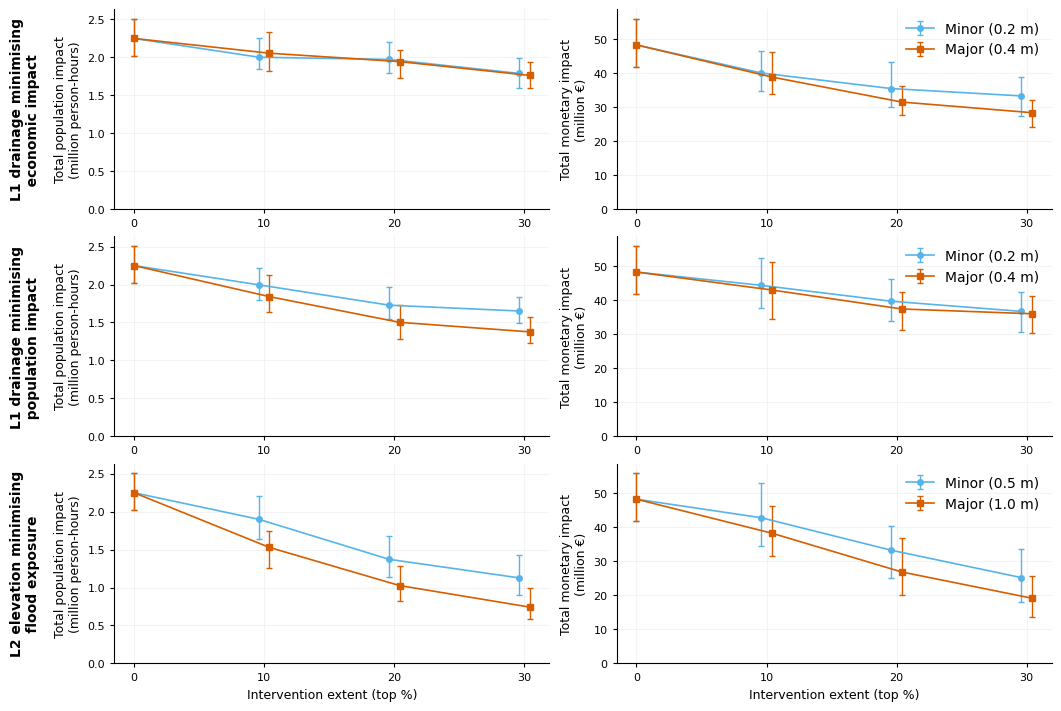

Figure ? saved: fig_dose_response.png


In [29]:
# ── Figure ? — Structural adaptations: dose–response (whiskers + fixed €) ─────
# Rows  : adaptation option (L1 monetary | L1 population | L2 elevation)
# Cols  : metric (population | monetary)
# Points: median across runs, whiskers = 5–95%
# x-axis: intervention extent 0, 10, 20, 30 %
# Key fix: monetary_impact_total treated as cumulative → use final timestep, not sum-over-time.

import numpy as np
import matplotlib.pyplot as plt

EXTENTS = [0, 10, 20, 30]

# --- Policy sets (as you defined) ---
# Policy sets: {extent: policy_name}
POLICY_SETS = {
    'L1 monetary (minor)': {
        0:  'baseline',
        10: 'L1_only_policy_L1_area_monetary_top10_red_0.2',
        20: 'L1_only_policy_L1_area_monetary_top20_red_0.2',
        30: 'L1_only_policy_L1_area_monetary_top30_red_0.2',
    },
    'L1 monetary (major)': {
        0:  'baseline',
        10: 'L1_only_policy_L1_area_monetary_top10_red_0.4',
        20: 'L1_only_policy_L1_area_monetary_top20_red_0.4',
        30: 'L1_only_policy_L1_area_monetary_top30_red_0.4',
    },
    'L1 population (minor)': {
        0:  'baseline',
        10: 'L1_only_policy_L1_area_population_top10_red_0.2',
        20: 'L1_only_policy_L1_area_population_top20_red_0.2',
        30: 'L1_only_policy_L1_area_population_top30_red_0.2',
    },
    'L1 population (major)': {
        0:  'baseline',
        10: 'L1_only_policy_L1_area_population_top10_red_0.4',
        20: 'L1_only_policy_L1_area_population_top20_red_0.4',
        30: 'L1_only_policy_L1_area_population_top30_red_0.4',
    },
    'L2 elevation (minor)': {
        0:  'baseline',
        10: 'L2_only_exp_subs_top_10_0.5m',
        20: 'L2_only_exp_subs_top_20_0.5m',
        30: 'L2_only_exp_subs_top_30_0.5m',
    },
    'L2 elevation (major)': {
        0:  'baseline',
        10: 'L2_only_exp_subs_top_10_1.0m',
        20: 'L2_only_exp_subs_top_20_1.0m',
        30: 'L2_only_exp_subs_top_30_1.0m',
    },
}

ROW_DEFS = [
    ('L1 drainage minimising\n   economic impact',   'L1 monetary (minor)',   'L1 monetary (major)',   '0.2 m', '0.4 m'),
    ('L1 drainage minimising\n  population impact', 'L1 population (minor)', 'L1 population (major)', '0.2 m', '0.4 m'),
    ('L2 elevation minimising\n     flood exposure',  'L2 elevation (minor)',  'L2 elevation (major)',  '0.5 m', '1.0 m'),
]

COL_DEFS = [
    ('Population impacts', 'affected_population',   'Population burden\n(person-hours)'),
    ('Monetary impacts',   'monetary_impact_total', 'Monetary loss (€)'),
]

MINOR_COLOR = '#56b4e9'
MAJOR_COLOR = '#d55e00'

def _metric_total(out_arr, outcome_key):
    """
    Convert per-run time series to a scalar 'total' per run, consistent with paper logic.
    - affected_population: sum over time -> person-hours (or person-timesteps)
    - monetary_impact_total: assumed cumulative over time -> use final timestep only
    """
    if outcome_key == 'monetary_impact_total':
        return out_arr[:, -1]
    else:
        return out_arr.sum(axis=1)

def dose_response_stats(exp_df, out_dict, outcome_key, pol_dict, crew_mask):
    """
    For each extent, return median and 5–95% of the scalar total across runs.
    """
    med, p05, p95 = [], [], []
    for ext in EXTENTS:
        pol = pol_dict[ext]
        m = crew_mask & (exp_df['policy'] == pol)
        if m.sum() == 0:
            med.append(np.nan); p05.append(np.nan); p95.append(np.nan)
            continue
        series = out_dict[outcome_key][m.values]
        totals = _metric_total(series, outcome_key)
        med.append(float(np.median(totals)))
        p05.append(float(np.percentile(totals, 5)))
        p95.append(float(np.percentile(totals, 95)))
    return np.array(EXTENTS), np.array(med), np.array(p05), np.array(p95)

# --- Precompute all stats so we can set consistent y-limits per metric ---
stats = {}  # (row_label, col_label, minor/major) -> (x, med, p05, p95)

for row_label, minor_key, major_key, minor_lbl, major_lbl in ROW_DEFS:
    for col_label, outcome_key, _ in COL_DEFS:
        x_mn, med_mn, p05_mn, p95_mn = dose_response_stats(exp4, out4, outcome_key, POLICY_SETS[minor_key], crew_mask4)
        x_mj, med_mj, p05_mj, p95_mj = dose_response_stats(exp4, out4, outcome_key, POLICY_SETS[major_key], crew_mask4)
        stats[(row_label, col_label, 'minor')] = (x_mn, med_mn, p05_mn, p95_mn, minor_lbl)
        stats[(row_label, col_label, 'major')] = (x_mj, med_mj, p05_mj, p95_mj, major_lbl)


GLOBAL_YLIMS = {}

for col_label, outcome_key, _ in COL_DEFS:
    p95_all = []
    for row_label, *_ in ROW_DEFS:
        for which in ['minor', 'major']:
            _, med, p05, p95, _ = stats[(row_label, col_label, which)]
            p95_all.append(np.nanmax(p95 / 1e6))
    ymax = float(np.nanmax(p95_all))
    GLOBAL_YLIMS[col_label] = (0.0, ymax * 1.05)


# --- Consistent y-limits by metric (column) ---
ylim = {}
for col_label, outcome_key, _ in COL_DEFS:
    p95_all = []
    for row_label, *_ in ROW_DEFS:
        for which in ['minor', 'major']:
            _, _, _, p95v, _ = stats[(row_label, col_label, which)]
            p95_all.append(np.nanmax(p95v))
    ymax = float(np.nanmax(p95_all))
    ylim[col_label] = (0.0, ymax * 1.05 if ymax > 0 else 1.0)

# --- Sanity check for monetary scale (should be ~1e7–1e8, not 1e9) ---
mon_ymax = ylim['Monetary impacts'][1]
if mon_ymax > 5e8:
    print(f"WARNING: Monetary axis upper bound is {mon_ymax:.2e}. "
          "This suggests monetary_impact_total may not be cumulative, or is being aggregated incorrectly.")

# --- Plot ---
fig, axes = plt.subplots(len(ROW_DEFS), len(COL_DEFS), figsize=(10.5, 7), constrained_layout=True)


dx = 0.4  # horizontal offset to avoid whisker overlap

for r_idx, (row_label, minor_key, major_key, minor_lbl, major_lbl) in enumerate(ROW_DEFS):
    for c_idx, (col_label, outcome_key, ylab) in enumerate(COL_DEFS):
        ax = axes[r_idx, c_idx]

        # ----- Minor -----
        x, med, p05, p95, dlab = stats[(row_label, col_label, 'minor')]
        x_m = np.array(x, dtype=float)
        x_m[x != 0] -= dx  # shift non-baseline points left

        med_m = med / 1e6
        yerr_m = np.vstack([(med - p05) / 1e6, (p95 - med) / 1e6])

        ax.errorbar(
            x_m, med_m, yerr=yerr_m,
            fmt='o-', ms=4, lw=1.2, color=MINOR_COLOR,
            capsize=2, elinewidth=1.0,
            label=f"Minor ({minor_lbl})"
        )

        # ----- Major -----
        x, med, p05, p95, dlab = stats[(row_label, col_label, 'major')]
        x_M = np.array(x, dtype=float)
        x_M[x != 0] += dx  # shift non-baseline points right
        med_M = med / 1e6
        yerr_M = np.vstack([(med - p05) / 1e6, (p95 - med) / 1e6])

        ax.errorbar(
            x_M, med_M, yerr=yerr_M,
            fmt='s-', ms=4, lw=1.2, color=MAJOR_COLOR,
            capsize=2, elinewidth=1.0,
            label=f"Major ({major_lbl})"
        )

        ax.set_xticks(EXTENTS)
        ax.set_ylim(*GLOBAL_YLIMS[col_label])
        ax.grid(alpha=0.15)
        ax.tick_params(labelsize=8)

        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)

        # ----- Y labels on BOTH columns -----
        if c_idx == 0:
            ax.set_ylabel('Total population impact\n(million person-hours)', fontsize=9)
            ax.annotate(row_label, xy=(-0.24, 0.5), xycoords='axes fraction',
                        fontsize=10, fontweight='bold', rotation=90, va='center')
        else:
            ax.set_ylabel('Total monetary impact\n(million €)', fontsize=9)

        # ----- X labels -----
        if r_idx == len(ROW_DEFS) - 1:
            ax.set_xlabel('Intervention extent (top %)', fontsize=9)

        # ----- Row-specific legend (correct doses) -----
        if c_idx == 1:
            ax.legend(fontsize=10, frameon=False, loc='upper right')


fig.savefig(
    FIG_DIR / 'fig4_dose_response.png',
    dpi=600,
    bbox_inches='tight'
)
plt.show()

print("Figure ? saved: fig_dose_response.png")


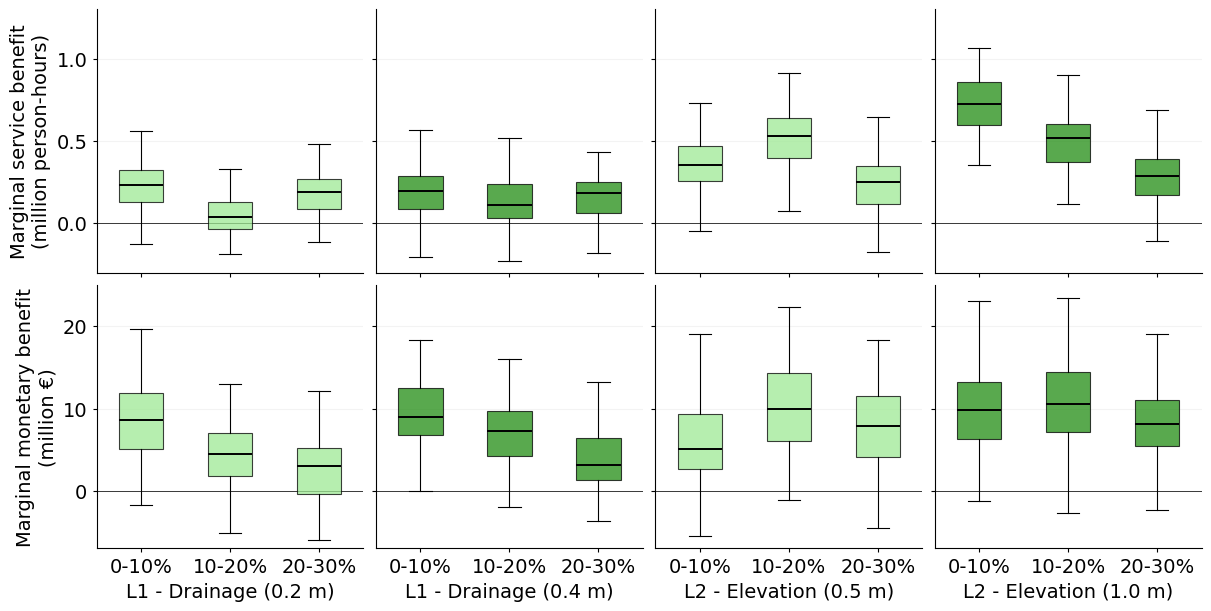

Figure ? saved: fig_marginal_dose_response_8panel.png


In [78]:
# ── Figure ? — Marginal dose–response (boxplots), 2×4 layout ─────────────────
# Rows: population / monetary
# Cols: L1 minor | L1 major | L2 minor | L2 major
# x-axis: 0-10%, 10-20%, 20-30%

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

# ── Styling ──
MINOR_COLOR   = "#9ee994"
MAJOR_COLOR   = "#228d13"

# ── Policy sets ──
EXTENTS = [0, 10, 20, 30]
DELTA_LABELS = ['0-10%', '10-20%', '20-30%']
DELTA_PAIRS = [(0, 10), (10, 20), (20, 30)]

POLICY_SETS = {
    'L1 minor': {
        0: 'baseline',
        10: 'L1_only_policy_L1_area_monetary_top10_red_0.2',
        20: 'L1_only_policy_L1_area_monetary_top20_red_0.2',
        30: 'L1_only_policy_L1_area_monetary_top30_red_0.2',
    },
    'L1 major': {
        0: 'baseline',
        10: 'L1_only_policy_L1_area_monetary_top10_red_0.4',
        20: 'L1_only_policy_L1_area_monetary_top20_red_0.4',
        30: 'L1_only_policy_L1_area_monetary_top30_red_0.4',
    },
    'L2 minor': {
        0: 'baseline',
        10: 'L2_only_exp_subs_top_10_0.5m',
        20: 'L2_only_exp_subs_top_20_0.5m',
        30: 'L2_only_exp_subs_top_30_0.5m',
    },
    'L2 major': {
        0: 'baseline',
        10: 'L2_only_exp_subs_top_10_1.0m',
        20: 'L2_only_exp_subs_top_20_1.0m',
        30: 'L2_only_exp_subs_top_30_1.0m',
    },
}

# ── Layout ──
ROW_DEFS = [
    ('affected_population',   'Marginal service benefit\n(million person-hours)', 1e6),
    ('monetary_impact_total', 'Marginal monetary benefit\n(million €)',            1e6),
]
COL_DEFS = [
    ('L1 - Drainage (0.2 m)', 'L1 minor', MINOR_COLOR),
    ('L1 - Drainage (0.4 m)', 'L1 major', MAJOR_COLOR),
    ('L2 - Elevation (0.5 m)', 'L2 minor', MINOR_COLOR),
    ('L2 - Elevation (1.0 m)', 'L2 major', MAJOR_COLOR),
]

# ── Helpers ──
def _metric_total(out_arr, outcome_key):
    if outcome_key == 'monetary_impact_total':
        return out_arr[:, -1]
    else:
        return out_arr.sum(axis=1)

_scenario_cols = [c for c in exp4.columns if c not in ('policy', 'model')]

def _paired_totals(exp_df, out_dict, outcome_key, policy, cmask):
    m = cmask & (exp_df['policy'] == policy)
    indices = np.where(m.values)[0]
    arr = out_dict[outcome_key][indices]
    totals = _metric_total(arr, outcome_key)
    return {tuple(exp_df.iloc[idx][_scenario_cols].values): totals[j]
            for j, idx in enumerate(indices)}

def _marginal_benefits(exp_df, out_dict, outcome_key, pol_dict, cmask, scale):
    by_ext = {ext: _paired_totals(exp_df, out_dict, outcome_key,
                                  pol_dict[ext], cmask)
              for ext in EXTENTS}
    deltas = []
    for lo, hi in DELTA_PAIRS:
        common = sorted(set(by_ext[lo]) & set(by_ext[hi]))
        if not common:
            deltas.append(np.array([np.nan]))
        else:
            deltas.append(np.array([(by_ext[lo][k] - by_ext[hi][k]) / scale
                                    for k in common]))
    return deltas

# ── Precompute ──
marginals = {}
for outcome_key, _, scale in ROW_DEFS:
    for _, pol_key, _ in COL_DEFS:
        marginals[(outcome_key, pol_key)] = _marginal_benefits(
            exp4, out4, outcome_key, POLICY_SETS[pol_key], crew_mask4, scale)

# ── Consistent y-limits per row ──
row_ylims = {}
for outcome_key, _, _ in ROW_DEFS:
    lo, hi = np.inf, -np.inf
    for _, pol_key, _ in COL_DEFS:
        for arr in marginals[(outcome_key, pol_key)]:
            if np.all(np.isnan(arr)):
                continue
            lo = min(lo, float(np.percentile(arr, 1)))
            hi = max(hi, float(np.percentile(arr, 99)))
    pad = (hi - lo) * 0.1
    row_ylims[outcome_key] = (lo - pad, hi + pad)

# ── Plot ──
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharey='row', sharex='col', constrained_layout=True)

box_w = 0.5

for r, (outcome_key, ylab, _) in enumerate(ROW_DEFS):
    for c, (col_title, pol_key, col_color) in enumerate(COL_DEFS):
        ax = axes[r, c]
        data = marginals[(outcome_key, pol_key)]

        ax.boxplot(
            data, positions=[0, 1, 2], widths=box_w,
            patch_artist=True, showfliers=False,
            boxprops=dict(facecolor=col_color, alpha=0.75, linewidth=0.8),
            medianprops=dict(color='black', linewidth=1.4),
            whiskerprops=dict(color='black', linewidth=0.8),
            capprops=dict(color='black', linewidth=0.8),
        )

        ax.set_xticks(range(3))
        ax.set_xticklabels(DELTA_LABELS, fontsize=14)
        ax.axhline(0, color='black', lw=0.6, zorder=0)
        ax.set_ylim(*row_ylims[outcome_key])
        ax.grid(axis='y', alpha=0.15, zorder=0)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        ax.tick_params(labelsize=14)

        # x-label = lever name (bottom row only)
        if r == 1:
            ax.set_xlabel(col_title, fontsize=14)
        if c == 0:
            ax.set_ylabel(ylab, fontsize=14)

axes[0, 0].yaxis.set_major_locator(MultipleLocator(0.5))
axes[0, 0].set_ylim(-0.3, 1.3)
axes[1, 0].yaxis.set_major_locator(MultipleLocator(10))
axes[1, 0].set_ylim(-7, 25)

fig.savefig(FIG_DIR / 'fig_marginal_dose_response_8panel.png', dpi=600, bbox_inches='tight')
plt.show()
print("Figure ? saved: fig_marginal_dose_response_8panel.png")

In [69]:
len(marginals[('affected_population', 'L1 minor')][0])

100

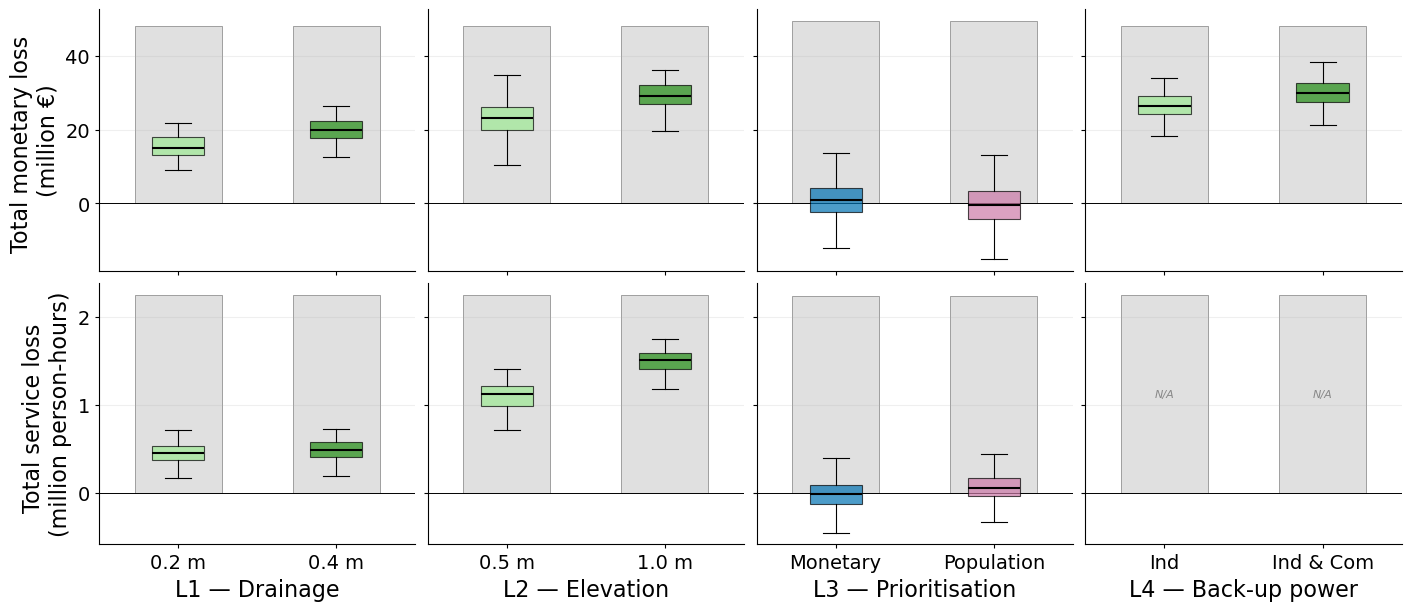

Figure 4 saved: fig4_lever_boxplot_benefits.png


In [ ]:
# ── Figure 4 (new) — Box-plot benefits overlaid on baseline bars ──────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

# ── Styling ──
BASE_COLOR    = '#e0e0e0'
MINOR_COLOR   = "#9ee994"
MAJOR_COLOR   = "#228d13"
L3_MON_COLOR  = '#0072b2'
L3_POP_COLOR  = '#cc79a7'
BAR_W         = 0.55

# ── Helpers ──
def _total_metric(arr_2d, outcome_key):
    """Scalar total per run: final timestep for monetary (cumulative), sum for population."""
    return arr_2d[:, -1] if outcome_key == 'monetary_impact_total' else arr_2d.sum(axis=1)

def _get_totals(exp_df, out_dict, outcome_key, policy, cmask):
    m = cmask & (exp_df['policy'] == policy)
    return _total_metric(out_dict[outcome_key][m.values], outcome_key)

def _get_sector_finals(exp_df, out_dict, sector_key, policy, cmask):
    m = cmask & (exp_df['policy'] == policy)
    return out_dict[sector_key][m.values][:, -1]

# ── Policies (top-30 % only, matching existing Figure 4) ──
L1_MINOR_POL = 'L1_only_policy_L1_area_monetary_top30_red_0.2'
L1_MAJOR_POL = 'L1_only_policy_L1_area_monetary_top30_red_0.4'
L2_MINOR_POL = 'L2_only_exp_subs_top_30_0.5m'
L2_MAJOR_POL = 'L2_only_exp_subs_top_30_1.0m'
L3_BASE_POL  = 'baseline_road'
L3_MON_POL   = 'monetary_impacts_road'
L3_POP_POL   = 'population_impacts_road'
IND_KEY      = 'monetary_impact_industrial'
COM_KEY      = 'monetary_impact_commercial'

# ── Row / column layout ──
ROW_DEFS = [
    ('monetary_impact_total', 'Total monetary loss \n(million €)',           1e6),
    ('affected_population',   'Total service loss \n(million person-hours)', 1e6),
]
COL_TITLES = ['L1 — Drainage', 'L2 — Elevation',
              'L3 — Prioritisation', 'L4 — Back-up power']

# ── Build figure ──
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharey='row', sharex='col', constrained_layout=True)

for r, (outcome_key, ylab, scale) in enumerate(ROW_DEFS):

    # Baselines (L1/L2/L4 share one dataset; L3 uses the no-adaptations dataset)
    bl_L12_med = float(np.median(_get_totals(exp4, out4, outcome_key, 'baseline', crew_mask4) / scale))
    bl_L3_med  = float(np.median(_get_totals(exp, out, outcome_key, L3_BASE_POL, crew_mask) / scale))

    # Per-column definitions
    col_defs = [
        {   # L1
            'policies': [L1_MINOR_POL, L1_MAJOR_POL],
            'tick_labels': ['0.2 m', '0.4 m'],
            'colors':   [MINOR_COLOR, MAJOR_COLOR],
            'bl_med':   bl_L12_med,
            'exp': exp4, 'out': out4, 'cmask': crew_mask4,
            'special':  None,
        },
        {   # L2
            'policies': [L2_MINOR_POL, L2_MAJOR_POL],
            'tick_labels': ['0.5 m', '1.0 m'],
            'colors':   [MINOR_COLOR, MAJOR_COLOR],
            'bl_med':   bl_L12_med,
            'exp': exp4, 'out': out4, 'cmask': crew_mask4,
            'special':  None,
        },
        {   # L3
            'policies': [L3_MON_POL, L3_POP_POL],
            'tick_labels': ['Monetary', 'Population'],
            'colors':   [L3_MON_COLOR, L3_POP_COLOR],
            'bl_med':   bl_L3_med,
            'exp': exp, 'out': out, 'cmask': crew_mask,
            'special':  None,
        },
        {   # L4
            'policies': ['baseline', 'baseline'],
            'tick_labels': ['Ind', 'Ind & Com'],
            'colors':   [MINOR_COLOR, MAJOR_COLOR],
            'bl_med':   bl_L12_med,
            'exp': exp4, 'out': out4, 'cmask': crew_mask4,
            'special':  'L4',
        },
    ]

    for c, cdef in enumerate(col_defs):
        ax     = axes[r, c]
        bl_med = cdef['bl_med']

        for i, (pol, col) in enumerate(
                zip(cdef['policies'], cdef['colors'])):

            # Grey baseline bar
            ax.bar(i, bl_med, color=BASE_COLOR, width=BAR_W,
                   edgecolor='grey', linewidth=0.5, zorder=1)

            # Compute per-run benefits
            if cdef['special'] == 'L4':
                if outcome_key == 'monetary_impact_total':
                    ind = _get_sector_finals(cdef['exp'], cdef['out'],
                                             IND_KEY, 'baseline', cdef['cmask']) / scale
                    com = _get_sector_finals(cdef['exp'], cdef['out'],
                                             COM_KEY, 'baseline', cdef['cmask']) / scale
                    benefits = ind if i == 0 else ind + com
                else:
                    ax.text(i, bl_med * 0.5, 'N/A', ha='center', va='center',
                            fontsize=8, fontstyle='italic', color='#888888', zorder=4)
                    continue
            else:
                adapted  = _get_totals(cdef['exp'], cdef['out'],
                                       outcome_key, pol, cdef['cmask']) / scale
                benefits = bl_med - adapted

            # Box plot overlaid on the bar
            ax.boxplot(
                [benefits], positions=[i], widths=BAR_W * 0.6,
                patch_artist=True, zorder=3,
                boxprops=dict(facecolor=col, alpha=0.7, linewidth=0.8),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                showfliers=False,
            )

        # Tick labels
        ax.set_xticks(range(len(cdef['tick_labels'])))
        ax.set_xticklabels(cdef['tick_labels'], fontsize=14)
        ax.axhline(0, color='black', lw=0.7, zorder=2)
        ax.grid(axis='y', alpha=0.2, zorder=0)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)

        # X-axis label on bottom row only
        if r == 1:
            ax.set_xlabel(COL_TITLES[c], fontsize=16)

    axes[r, 0].set_ylabel(ylab, fontsize=16)

axes[1, 0].yaxis.set_major_locator(MultipleLocator(1))

fig.savefig(FIG_DIR / 'fig4_lever_boxplot_benefits.png', dpi=600, bbox_inches='tight')
plt.show()
print("Figure 4 saved: fig4_lever_boxplot_benefits.png")

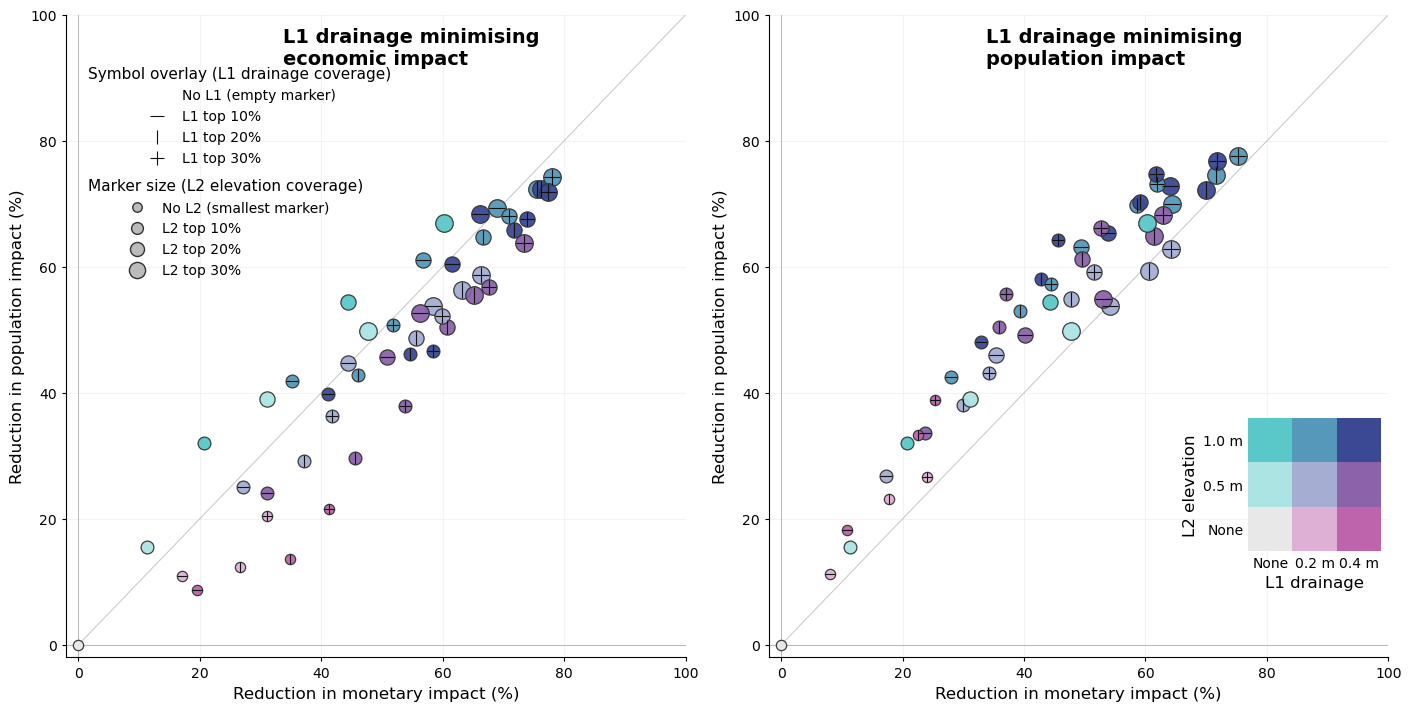

Figure 5 saved: fig5_tradeoffs_bivariate_symbols.png


In [24]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb

# ----------------------------- Palette (your accessible 3x3) ------------------
# Rows: L2 intensity (None, Minor, Major) bottom -> top
# Cols: L1 intensity (None, Minor, Major) left  -> right
BIVAR_BLUE_GOLD = np.array([
    ['#E8EAEE', '#EDD9B3', '#F2C778'],  # L2 none
    ['#B8C6DE', '#C2B6B9', '#CCA694'],  # L2 minor
    ['#89A1C8', '#928DA4', '#9A7680'],  # L2 major
], dtype=object)

BIVAR_PINK_BLUE = np.array([
    ["#E8E8E8", "#DFB0D6", "#BE64AC"], # Low Y
    ["#ACE4E4", "#A5ADD3", "#8C62AA"], # Mid Y
    ["#5AC8C8", "#5698B9", "#3B4994"]  # High Y
], dtype=object)

BIVAR_BLUE_ORANGE = np.array([
    ["#F3F3F3", "#F4D3BA", "#E6A176"], # Low Y
    ["#BAD3F4", "#A8A8A8", "#8E7C6B"], # Mid Y
    ["#76A1E6", "#6B7C8E", "#4D4D4D"]  # High Y
], dtype=object)

BIVAR_YELLOW_BLUE = np.array([
    ["#E8E8E8", "#E4D354", "#D3D100"], # Low Y
    ["#98B9D1", "#8C96C6", "#6E6EA0"], # Mid Y
    ["#4271A1", "#3B4994", "#1F1F5E"]  # High Y
], dtype=object)

# Convert to numeric RGB for imshow
BIVAR_HEX = BIVAR_PINK_BLUE
BIVAR_RGB = np.array([[to_rgb(h) for h in row] for row in BIVAR_HEX], dtype=float)

L1_LEVELS = [0.0, 0.2, 0.4]   # none/minor/major
L2_LEVELS = [0.0, 0.5, 1.0]   # none/minor/major

def level_index(val, levels):
    return levels.index(val)

def bivar_color(l1_red, l2_elev):
    xi = level_index(l1_red, L1_LEVELS)   # col index
    yi = level_index(l2_elev, L2_LEVELS)  # row index
    return BIVAR_HEX[yi, xi]

# ----------------------------- Coverage encoding ------------------------------
# Use ONLY circles so marker size is interpretable.
# L2 coverage -> size (points^2)
SIZE_MAP_L2 = {0: 55, 10: 85, 20: 120, 30: 160}

# L1 coverage -> symbol overlay
# 0 = no symbol, 10='-', 20='|', 30='+'
L1C_SYMBOL = {0: None, 10: '_', 20: '|', 30: '+'}
SYMBOL_SIZE = 13            # size of overlay symbol
SYMBOL_COLOR = '#111111'
SYMBOL_EDGEWIDTH = 0.8      # thickness for | and +

EDGE_COLOR = '#333333'
EDGE_WIDTH = 0.9

# ----------------------------- Pareto (optional outline only) -----------------
def pareto_mask(costs):
    costs = np.asarray(costs)
    n = costs.shape[0]
    is_eff = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_eff[i]:
            continue
        dominated = (np.all(costs <= costs[i], axis=1) & np.any(costs < costs[i], axis=1))
        dominated[i] = False
        if np.any(dominated):
            is_eff[i] = False
    return is_eff

# ----------------------------- Policy parsing ---------------------------------
re_l1_only = re.compile(r'^L1_only_policy_L1_area_(monetary|population)_top(\d+)_red_(0\.2|0\.4)$')
re_l2_only = re.compile(r'^L2_only_exp_subs_top_(\d+)_(0\.5|1\.0)m$')
re_l1l2 = re.compile(
    r'^L1L2_policy_L1_area_(monetary|population)_top(\d+)_red_(0\.2|0\.4)_exp_subs_top_(\d+)_(0\.5|1\.0)m$'
)

def parse_policy(pol):
    if pol == 'baseline':
        return dict(rank='none', l1_cov=0, l1_red=0.0, l2_cov=0, l2_elev=0.0)

    m = re_l1_only.match(pol)
    if m:
        rank, l1_cov, l1_red = m.group(1), int(m.group(2)), float(m.group(3))
        return dict(rank=rank, l1_cov=l1_cov, l1_red=l1_red, l2_cov=0, l2_elev=0.0)

    m = re_l2_only.match(pol)
    if m:
        l2_cov, l2_elev = int(m.group(1)), float(m.group(2))
        return dict(rank='none', l1_cov=0, l1_red=0.0, l2_cov=l2_cov, l2_elev=l2_elev)

    m = re_l1l2.match(pol)
    if m:
        rank = m.group(1)
        l1_cov, l1_red = int(m.group(2)), float(m.group(3))
        l2_cov, l2_elev = int(m.group(4)), float(m.group(5))
        return dict(rank=rank, l1_cov=l1_cov, l1_red=l1_red, l2_cov=l2_cov, l2_elev=l2_elev)

    return None

# ----------------------------- Totals -----------------------------------------
def monetary_total(series_2d):
    return series_2d[:, -1]     # cumulative -> final

def population_total(series_2d):
    return series_2d.sum(axis=1)  # instantaneous -> sum

# ----------------------------- Build records ----------------------------------
available_pols = sorted(set(exp4.loc[crew_mask4, 'policy'].unique()))
records = []
for pol in available_pols:
    parsed = parse_policy(pol)
    if parsed is None:
        continue
    parsed['policy'] = pol
    records.append(parsed)

if not records:
    raise ValueError("No matching L1/L2 policies found in exp4; check naming patterns.")

mon_arr = out4['monetary_impact_total']
pop_arr = out4['affected_population']

for r in records:
    pol = r['policy']
    m = crew_mask4 & (exp4['policy'] == pol)
    mon = monetary_total(mon_arr[m.values]) / 1e6
    pop = population_total(pop_arr[m.values]) / 1e6
    r['mon_median'] = float(np.median(mon))
    r['pop_median'] = float(np.median(pop))

baseline = [r for r in records if r['policy'] == 'baseline']
if not baseline:
    raise ValueError("Baseline not found under crew_mask4.")
baseline = baseline[0]

# --- Baseline reference values (medians) ---
M0 = baseline['mon_median']
P0 = baseline['pop_median']


# ----------------------------- Plot (two panels) ------------------------------
PANELS = [('L1 drainage minimising\neconomic impact', 'monetary'), ('L1 drainage minimising\npopulation impact', 'population')]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

for ax, (panel_name, rank_key) in zip(axes, PANELS):
    panel_recs = [baseline] + [
        r for r in records
        if r['policy'] != 'baseline' and (r['rank'] == 'none' or r['rank'] == rank_key)
    ]

    # Deduplicate by policy
    seen = set()
    uniq = []
    for r in panel_recs:
        if r['policy'] in seen:
            continue
        seen.add(r['policy'])
        uniq.append(r)
    panel_recs = uniq

    X = np.array([r['mon_median'] for r in panel_recs])
    Y = np.array([r['pop_median'] for r in panel_recs])

    is_pf = pareto_mask(np.column_stack([X, Y]))
    pf_idx = np.where(is_pf)[0]

    # scatter points
    for i, r in enumerate(panel_recs):

        x = 100.0 * (M0 - r['mon_median']) / M0
        y = 100.0 * (P0 - r['pop_median']) / P0

        fc = bivar_color(r['l1_red'], r['l2_elev'])
        s = SIZE_MAP_L2.get(r['l2_cov'], 90)

        ax.scatter(x, y, s=s, marker='o',
                facecolors=fc, edgecolors=EDGE_COLOR,
                linewidths=EDGE_WIDTH, alpha=0.95, zorder=4)

        sym = L1C_SYMBOL.get(r['l1_cov'], None)
        if sym is not None:
            base_area = SIZE_MAP_L2.get(r['l2_cov'], SIZE_MAP_L2[0])
            sym_size = np.sqrt(base_area) * 0.9
            ax.plot([x], [y], linestyle='',
                    marker=sym, color=SYMBOL_COLOR,
                    markersize=sym_size,
                    markeredgewidth=SYMBOL_EDGEWIDTH,
                    zorder=6)

    ax.axhline(0, color='#bbbbbb', lw=0.6, zorder=1)
    ax.axvline(0, color='#bbbbbb', lw=0.6, zorder=1)

    # diagonal and shared limits
    lim = 100
    ax.plot([0, lim], [0, lim], color='#cccccc', lw=0.8, zorder=1)
    ax.set_xlim(-2, lim)
    ax.set_ylim(-2, lim)

    ax.grid(alpha=0.10)

    
    ax.axhline(0, color='#bbbbbb', lw=0.6, zorder=1)
    ax.axvline(0, color='#bbbbbb', lw=0.6, zorder=1)

    ax.set_xlabel('Reduction in monetary impact (%)', fontsize=12)
    ax.set_ylabel('Reduction in population impact (%)', fontsize=12)

    ax.tick_params(labelsize=10)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.grid(alpha=0.15)
    ax.text(0.35, 0.98, panel_name, transform=ax.transAxes,
            ha='left', va='top', fontsize=14, fontweight='bold')
    
# ----------------------------- Legends ----------------------------------------
# 3x3 bivariate palette legend (now works: numeric RGB)
ax_sw = fig.add_axes([0.84, 0.22, 0.19, 0.19])  # [left, bottom, width, height]
ax_sw.imshow(BIVAR_RGB, origin='lower')
ax_sw.set_xticks([0, 1, 2]); ax_sw.set_yticks([0, 1, 2])
ax_sw.set_xticklabels(['None', '0.2 m', '0.4 m'], fontsize=10)
ax_sw.set_yticklabels(['None', '0.5 m', '1.0 m'], fontsize=10)
ax_sw.set_xlabel('L1 drainage', fontsize=12)
ax_sw.set_ylabel('L2 elevation', fontsize=12)
for sp in ['top', 'right', 'left', 'bottom']:
    ax_sw.spines[sp].set_visible(False)
ax_sw.tick_params(length=0)

# L2 coverage size legend (circles)
size_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor='#bbbbbb', markeredgecolor=EDGE_COLOR,
               markersize=np.sqrt(SIZE_MAP_L2[0] * 0.85),
               label='No L2 (smallest marker)')
]

size_handles += [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor='#bbbbbb', markeredgecolor=EDGE_COLOR,
               markersize=np.sqrt(SIZE_MAP_L2[p] * 0.85),
               label=f'L2 top {p}%')
    for p in [10, 20, 30]
]

# L1 coverage symbol legend
sym_handles = [
    plt.Line2D([0], [0], marker=L1C_SYMBOL[p] if L1C_SYMBOL[p] else 'None',
               linestyle='', color=SYMBOL_COLOR,
               markersize=10, markeredgewidth=SYMBOL_EDGEWIDTH,
               label=f'L1 top {p}%')
    for p in [0, 10, 20, 30]
    if p != 0
]
sym_handles = [
    plt.Line2D([0], [0], linestyle='', color=SYMBOL_COLOR, label='No L1 (empty marker)')
] + sym_handles

fig.legend(handles=sym_handles, loc='upper left',
           bbox_to_anchor=(0.05, 0.93), frameon=False, fontsize=10,
           title='Symbol overlay (L1 drainage coverage)', title_fontsize=11)
fig.legend(handles=size_handles, loc='upper left',
           bbox_to_anchor=(0.05, 0.77), frameon=False, fontsize=10,
           title='Marker size (L2 elevation coverage)', title_fontsize=11)


fig.savefig(FIG_DIR / 'fig5_tradeoffs_bivariate_symbols.png', dpi=600, bbox_inches='tight')
plt.show()

print("Figure 5 saved: fig5_tradeoffs_bivariate_symbols.png")

In [25]:
L1_count=0
L2_count=0

for i in exp4['policy'].unique():
    if "L1" in i:
        L1_count += 1
    if "L2" in i:
        L2_count += 1
    if not ("L1" in i or "L2" in i):
        print(i)

print(f"Number of policies with L1: {L1_count}")
print(f"Number of policies with L2: {L2_count}")

population_impacts_policy
monetary_impacts_policy
lowest_repair_time_islands_policy
highest_repair_time_islands_policy
baseline
Number of policies with L1: 84
Number of policies with L2: 78


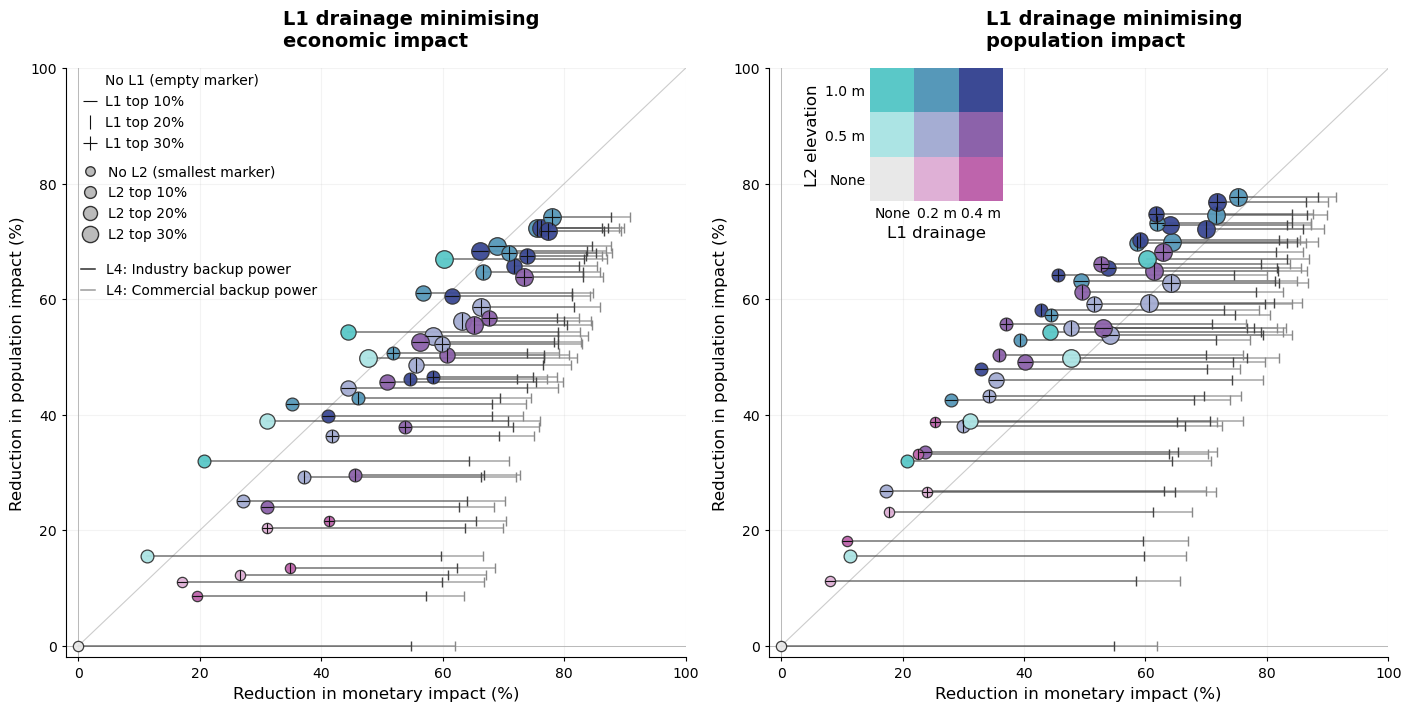

Figure 5 saved: fig5_combinations.png


In [26]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb

# ----------------------------- Palette (your accessible 3x3) ------------------
# Rows: L2 intensity (None, Minor, Major) bottom -> top
# Cols: L1 intensity (None, Minor, Major) left  -> right

BIVAR_PINK_BLUE = np.array([
    ["#E8E8E8", "#DFB0D6", "#BE64AC"], # Low Y
    ["#ACE4E4", "#A5ADD3", "#8C62AA"], # Mid Y
    ["#5AC8C8", "#5698B9", "#3B4994"]  # High Y
], dtype=object)

# Convert to numeric RGB for imshow
BIVAR_HEX = BIVAR_PINK_BLUE
BIVAR_RGB = np.array([[to_rgb(h) for h in row] for row in BIVAR_HEX], dtype=float)

L1_LEVELS = [0.0, 0.2, 0.4]   # none/minor/major
L2_LEVELS = [0.0, 0.5, 1.0]   # none/minor/major

def level_index(val, levels):
    return levels.index(val)

def bivar_color(l1_red, l2_elev):
    xi = level_index(l1_red, L1_LEVELS)   # col index
    yi = level_index(l2_elev, L2_LEVELS)  # row index
    return BIVAR_HEX[yi, xi]

# ----------------------------- Coverage encoding ------------------------------
# Use ONLY circles so marker size is interpretable.
# L2 coverage -> size (points^2)
SIZE_MAP_L2 = {0: 55, 10: 85, 20: 120, 30: 160}

# L1 coverage -> symbol overlay
# 0 = no symbol, 10='-', 20='|', 30='+'
L1C_SYMBOL = {0: None, 10: '_', 20: '|', 30: '+'}
SYMBOL_SIZE = 13            # size of overlay symbol
SYMBOL_COLOR = '#111111'
SYMBOL_EDGEWIDTH = 0.8      # thickness for | and +

EDGE_COLOR = '#333333'
EDGE_WIDTH = 0.9

# ----------------------------- Pareto (optional outline only) -----------------
def pareto_mask(costs):
    costs = np.asarray(costs)
    n = costs.shape[0]
    is_eff = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_eff[i]:
            continue
        dominated = (np.all(costs <= costs[i], axis=1) & np.any(costs < costs[i], axis=1))
        dominated[i] = False
        if np.any(dominated):
            is_eff[i] = False
    return is_eff

# ----------------------------- Policy parsing ---------------------------------
re_l1_only = re.compile(r'^L1_only_policy_L1_area_(monetary|population)_top(\d+)_red_(0\.2|0\.4)$')
re_l2_only = re.compile(r'^L2_only_exp_subs_top_(\d+)_(0\.5|1\.0)m$')
re_l1l2 = re.compile(
    r'^L1L2_policy_L1_area_(monetary|population)_top(\d+)_red_(0\.2|0\.4)_exp_subs_top_(\d+)_(0\.5|1\.0)m$'
)

def parse_policy(pol):
    if pol == 'baseline':
        return dict(rank='none', l1_cov=0, l1_red=0.0, l2_cov=0, l2_elev=0.0)

    m = re_l1_only.match(pol)
    if m:
        rank, l1_cov, l1_red = m.group(1), int(m.group(2)), float(m.group(3))
        return dict(rank=rank, l1_cov=l1_cov, l1_red=l1_red, l2_cov=0, l2_elev=0.0)

    m = re_l2_only.match(pol)
    if m:
        l2_cov, l2_elev = int(m.group(1)), float(m.group(2))
        return dict(rank='none', l1_cov=0, l1_red=0.0, l2_cov=l2_cov, l2_elev=l2_elev)

    m = re_l1l2.match(pol)
    if m:
        rank = m.group(1)
        l1_cov, l1_red = int(m.group(2)), float(m.group(3))
        l2_cov, l2_elev = int(m.group(4)), float(m.group(5))
        return dict(rank=rank, l1_cov=l1_cov, l1_red=l1_red, l2_cov=l2_cov, l2_elev=l2_elev)

    return None

# ----------------------------- Totals -----------------------------------------
def monetary_total(series_2d):
    return series_2d[:, -1]     # cumulative -> final

def population_total(series_2d):
    return series_2d.sum(axis=1)  # instantaneous -> sum

# ----------------------------- Build records ----------------------------------
available_pols = sorted(set(exp4.loc[crew_mask4, 'policy'].unique()))
records = []
for pol in available_pols:
    parsed = parse_policy(pol)
    if parsed is None:
        continue
    parsed['policy'] = pol
    records.append(parsed)

if not records:
    raise ValueError("No matching L1/L2 policies found in exp4; check naming patterns.")

mon_arr = out4['monetary_impact_total']
pop_arr = out4['affected_population']

ind_arr = out4['monetary_impact_industrial']
com_arr = out4['monetary_impact_commercial']


for r in records:
    pol = r['policy']
    m = crew_mask4 & (exp4['policy'] == pol)
    mon = monetary_total(mon_arr[m.values]) / 1e6
    pop = population_total(pop_arr[m.values]) / 1e6

    r['mon_median'] = float(np.median(mon))
    r['pop_median'] = float(np.median(pop))


baseline = [r for r in records if r['policy'] == 'baseline']
if not baseline:
    raise ValueError("Baseline not found under crew_mask4.")
baseline = baseline[0]

# --- Baseline reference values (medians) ---
M0 = baseline['mon_median']
P0 = baseline['pop_median']


# ----------------------------- Plot (two panels) ------------------------------
PANELS = [('L1 drainage minimising\neconomic impact', 'monetary'), ('L1 drainage minimising\npopulation impact', 'population')]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

max_x_seen = 0.0
for ax, (panel_name, rank_key) in zip(axes, PANELS):
    panel_recs = [baseline] + [
        r for r in records
        if r['policy'] != 'baseline' and (r['rank'] == 'none' or r['rank'] == rank_key)
    ]

    # Deduplicate by policy
    seen = set()
    uniq = []
    for r in panel_recs:
        if r['policy'] in seen:
            continue
        seen.add(r['policy'])
        uniq.append(r)
    panel_recs = uniq

    X = np.array([r['mon_median'] for r in panel_recs])
    Y = np.array([r['pop_median'] for r in panel_recs])

    is_pf = pareto_mask(np.column_stack([X, Y]))
    pf_idx = np.where(is_pf)[0]

    # scatter points
    for i, r in enumerate(panel_recs):

        x = 100.0 * (M0 - r['mon_median']) / M0
        y = 100.0 * (P0 - r['pop_median']) / P0

        # L4 valuation bars: show how much further x would move if industry and commerce losses are ignored
        m_mask = crew_mask4 & (exp4['policy'] == r['policy'])

        # sector components for this policy (million €), consistent with monetary_total 
        ind_med = float(np.median(ind_arr[m_mask.values][:, -1] / 1e6))
        com_med = float(np.median(com_arr[m_mask.values][:, -1] / 1e6))

        # convert to % of baseline total (M0 is baseline total in million €)
        dx_ind = 100.0 * ind_med / M0 if M0 != 0 else 0.0
        dx_com = 100.0 * com_med / M0 if M0 != 0 else 0.0

        x_ind_end = x + dx_ind
        x_com_end = x_ind_end + dx_com

        # draw two horizontal segments (industry then commerce)
        ax.plot([x, x_ind_end], [y, y],
                color='#444444', lw=1.1, alpha=0.75, zorder=3)
        ax.plot([x_ind_end, x_com_end], [y, y],
                color='#888888', lw=1.1, alpha=0.75, zorder=3)

        # small ticks at segment boundaries (optional but helps readability)
        ax.plot([x_ind_end], [y], marker='|', color='#444444', markersize=7, zorder=4)
        ax.plot([x_com_end], [y], marker='|', color='#888888', markersize=7, zorder=4)

        # track max x for axis limits (define max_x_seen = 0 before the loop)
        max_x_seen = max(max_x_seen, x_com_end)


        fc = bivar_color(r['l1_red'], r['l2_elev'])
        s = SIZE_MAP_L2.get(r['l2_cov'], 90)

        ax.scatter(x, y, s=s, marker='o',
                facecolors=fc, edgecolors=EDGE_COLOR,
                linewidths=EDGE_WIDTH, alpha=0.95, zorder=4)

        sym = L1C_SYMBOL.get(r['l1_cov'], None)
        if sym is not None:
            base_area = SIZE_MAP_L2.get(r['l2_cov'], SIZE_MAP_L2[0])
            sym_size = np.sqrt(base_area) * 0.9
            ax.plot([x], [y], linestyle='',
                    marker=sym, color=SYMBOL_COLOR,
                    markersize=sym_size,
                    markeredgewidth=SYMBOL_EDGEWIDTH,
                    zorder=6)

    ax.axhline(0, color='#bbbbbb', lw=0.6, zorder=1)
    ax.axvline(0, color='#bbbbbb', lw=0.6, zorder=1)

    # diagonal and shared limits
    lim = 100
    ax.plot([0, lim], [0, lim], color='#cccccc', lw=0.8, zorder=1)
    ax.set_xlim(-2, lim)
    ax.set_ylim(-2, lim)

    ax.grid(alpha=0.10)

    
    ax.axhline(0, color='#bbbbbb', lw=0.6, zorder=1)
    ax.axvline(0, color='#bbbbbb', lw=0.6, zorder=1)

    ax.set_xlabel('Reduction in monetary impact (%)', fontsize=12)
    ax.set_ylabel('Reduction in population impact (%)', fontsize=12)

    ax.tick_params(labelsize=10)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.grid(alpha=0.15)
    ax.text(0.35, 1.10, panel_name, transform=ax.transAxes,
            ha='left', va='top', fontsize=14, fontweight='bold')
    
# ----------------------------- Legends ----------------------------------------
# 3x3 bivariate palette legend (now works: numeric RGB)
ax_sw = fig.add_axes([0.57, 0.72, 0.19, 0.19])  # [left, bottom, width, height]
ax_sw.imshow(BIVAR_RGB, origin='lower')
ax_sw.set_xticks([0, 1, 2]); ax_sw.set_yticks([0, 1, 2])
ax_sw.set_xticklabels(['None', '0.2 m', '0.4 m'], fontsize=10)
ax_sw.set_yticklabels(['None', '0.5 m', '1.0 m'], fontsize=10)
ax_sw.set_xlabel('L1 drainage', fontsize=12)
ax_sw.set_ylabel('L2 elevation', fontsize=12)
for sp in ['top', 'right', 'left', 'bottom']:
    ax_sw.spines[sp].set_visible(False)
ax_sw.tick_params(length=0)

# L2 coverage size legend (circles)
size_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor='#bbbbbb', markeredgecolor=EDGE_COLOR,
               markersize=np.sqrt(SIZE_MAP_L2[0] * 0.85),
               label='No L2 (smallest marker)')
]

size_handles += [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor='#bbbbbb', markeredgecolor=EDGE_COLOR,
               markersize=np.sqrt(SIZE_MAP_L2[p] * 0.85),
               label=f'L2 top {p}%')
    for p in [10, 20, 30]
]

# L1 coverage symbol legend
sym_handles = [
    plt.Line2D([0], [0], marker=L1C_SYMBOL[p] if L1C_SYMBOL[p] else 'None',
               linestyle='', color=SYMBOL_COLOR,
               markersize=10, markeredgewidth=SYMBOL_EDGEWIDTH,
               label=f'L1 top {p}%')
    for p in [0, 10, 20, 30]
    if p != 0
]
sym_handles = [
    plt.Line2D([0], [0], linestyle='', color=SYMBOL_COLOR, label='No L1 (empty marker)')
] + sym_handles

fig.legend(handles=sym_handles, loc='upper left',
           bbox_to_anchor=(0.05, 0.92), frameon=False, fontsize=10,
        #    title='Symbol overlay (L1 drainage coverage)', title_fontsize=11, 
           handlelength=0.2, handletextpad=1.0)
fig.legend(handles=size_handles, loc='upper left',
           bbox_to_anchor=(0.05, 0.79), frameon=False, fontsize=10,
        #    title='Marker size (L2 elevation coverage)', title_fontsize=11, 
           handlelength=0.2, handletextpad=1.2)

# L4 line legend
l4_handles = [
    plt.Line2D([0], [0], color="#2E2E2E", lw=1.1, label='L4: Industry backup power'),
    plt.Line2D([0], [0], color="#9B9B9B", lw=1.1, label='L4: Commercial backup power'),
]
fig.legend(handles=l4_handles, loc='upper left',
           bbox_to_anchor=(0.045, 0.65), frameon=False, fontsize=10,
        #    title='Line extension (L4 backup power)', title_fontsize=11, 
           handlelength=1.0, handletextpad=0.8)


fig.savefig(FIG_DIR / 'fig5_combinations.png', dpi=600, bbox_inches='tight')
plt.show()

print("Figure 5 saved: fig5_combinations.png")

In [27]:
outcomes

{'flooded': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(6000, 198)),
 'operational': array([[5858., 5858., 5858., ..., 5858., 5858., 5858.],
        [5858., 5858., 5858., ..., 5858., 5858., 5858.],
        [5858., 5858., 5858., ..., 5858., 5858., 5858.],
        ...,
        [5858., 5858., 5858., ..., 5858., 5858., 5858.],
        [5858., 5858., 5858., ..., 5858., 5858., 5858.],
        [5858., 5858., 5858., ..., 5858., 5858., 5858.]], shape=(6000, 198)),
 'unreachable': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(6000, 198)),
 'damage_ratio': array([[0., 0., 0., ..., 0., 0

In [28]:
outcomes.keys()

dict_keys(['flooded', 'operational', 'unreachable', 'damage_ratio', 'repair_time', 'timesteps', 'affected_population', 'served_population', 'affected_population_ratio', 'monetary_impact_total', 'monetary_impact_residential', 'monetary_impact_commercial', 'monetary_impact_industrial', 'monetary_impact_transport', 'monetary_impact_public_sector'])